<a href="https://www.kaggle.com/code/lalit7881/pl-2008-2026-matches-eda-47-13?scriptVersionId=347903839" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arjunsinghgangwar/ipl-20082026-matches-dataset/IPL_Matches_Data_2008_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/arjunsinghgangwar/ipl-20082026-matches-dataset/IPL_Matches_Data_2008_2026.csv")

In [3]:
df.head()

,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2007/08,1.0,18-04-2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2007/08,2.0,19-04-2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."
2,Indian Premier League,2007/08,3.0,19-04-2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,GA Pratapkumar,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
3,Indian Premier League,2007/08,4.0,20-04-2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,K Hariharan,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S..."
4,Indian Premier League,2007/08,5.0,20-04-2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,DJ Harper,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli..."


In [4]:
df.tail()

,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
1238,Indian Premier League,2026,70.0,24-05-2026,Kolkata,"Eden Gardens, Kolkata",Delhi Capitals,Kolkata Knight Riders,Kolkata Knight Riders,field,...,HAS Khalid,SJ Nogajski,M Krishnadas,T20,20,6,male,club,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G..."
1239,Indian Premier League,2026,NaN,26-05-2026,Dharamsala,"Himachal Pradesh Cricket Association Stadium, ...",Royal Challengers Bengaluru,Gujarat Titans,Gujarat Titans,field,...,VK Sharma,Nitin Menon,KN Ananthapadmanabhan,T20,20,6,male,club,"R Shepherd, VR Iyer, V Kohli, D Padikkal, RM P...","K Khejroliya, B Sai Sudharsan, Shubman Gill, J..."
1240,Indian Premier League,2026,NaN,27-05-2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,...,UV Gandhe,R Pandit,SJ Nogajski,T20,20,6,male,club,"YBK Jaiswal, V Suryavanshi, Dhruv Jurel, R Par...","PP Hinge, Abhishek Sharma, TM Head, Ishan Kish..."
1241,Indian Premier League,2026,NaN,29-05-2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Gujarat Titans,Rajasthan Royals,bat,...,SJ Nogajski,AT Holdstock,UV Gandhe,T20,20,6,male,club,"TU Deshpande, YBK Jaiswal, V Suryavanshi, Dhru...","Mohammed Siraj, B Sai Sudharsan, Shubman Gill,..."
1242,Indian Premier League,2026,NaN,31-05-2026,Ahmedabad,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,...,Nitin Menon,J Madanagopal,VK Sharma,T20,20,6,male,club,"M Prasidh Krishna, B Sai Sudharsan, Shubman Gi...","JA Duffy, VR Iyer, V Kohli, D Padikkal, RM Pat..."


In [5]:
df.info

<bound method DataFrame.info of                  event_name   season  match_number        date  \
0     Indian Premier League  2007/08           1.0  18-04-2008   
1     Indian Premier League  2007/08           2.0  19-04-2008   
2     Indian Premier League  2007/08           3.0  19-04-2008   
3     Indian Premier League  2007/08           4.0  20-04-2008   
4     Indian Premier League  2007/08           5.0  20-04-2008   
...                     ...      ...           ...         ...   
1238  Indian Premier League     2026          70.0  24-05-2026   
1239  Indian Premier League     2026           NaN  26-05-2026   
1240  Indian Premier League     2026           NaN  27-05-2026   
1241  Indian Premier League     2026           NaN  29-05-2026   
1242  Indian Premier League     2026           NaN  31-05-2026   

                city                                              venue  \
0          Bangalore                              M Chinnaswamy Stadium   
1         Chandigarh     

In [6]:
df.describe()

,match_number,team1_runs,team1_wickets,team2_runs,team2_wickets,win_by_runs,win_by_wickets,overs_limit,balls_per_over
count,1169.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.0,1243.0
mean,31.921300,165.851167,5.956557,157.349155,5.873693,13.932422,3.276750,20.0,6.0
std,18.626023,35.490847,2.309341,34.613073,2.646538,23.861556,3.358216,0.0,0.0
min,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.0,6.0
25%,16.000000,144.000000,4.000000,138.000000,4.000000,0.000000,0.000000,20.0,6.0
50%,32.000000,165.000000,6.000000,160.000000,6.000000,0.000000,3.000000,20.0,6.0
75%,47.000000,189.000000,8.000000,179.000000,8.000000,20.000000,6.000000,20.0,6.0
max,72.000000,287.000000,10.000000,265.000000,12.000000,146.000000,10.000000,20.0,6.0


In [7]:
df.isnull().sum()

event_name          0
season              0
match_number       74
date                0
city                0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
team1_runs          0
team1_wickets       0
team2_runs          0
team2_wickets       0
winner             25
result_type         0
win_by_runs         0
win_by_wickets      0
player_of_match     9
match_referee       0
umpire1             0
umpire2             0
tv_umpire           0
reserve_umpire      0
match_type          0
overs_limit         0
balls_per_over      0
gender              0
team_type           0
team1_players       0
team2_players       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['event_name', 'season', 'match_number', 'date', 'city', 'venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'team1_runs',
       'team1_wickets', 'team2_runs', 'team2_wickets', 'winner', 'result_type',
       'win_by_runs', 'win_by_wickets', 'player_of_match', 'match_referee',
       'umpire1', 'umpire2', 'tv_umpire', 'reserve_umpire', 'match_type',
       'overs_limit', 'balls_per_over', 'gender', 'team_type', 'team1_players',
       'team2_players'],
      dtype='object')

In [10]:
df.dtypes

event_name          object
season              object
match_number       float64
date                object
city                object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
team1_runs           int64
team1_wickets        int64
team2_runs           int64
team2_wickets        int64
winner              object
result_type         object
win_by_runs          int64
win_by_wickets       int64
player_of_match     object
match_referee       object
umpire1             object
umpire2             object
tv_umpire           object
reserve_umpire      object
match_type          object
overs_limit          int64
balls_per_over       int64
gender              object
team_type           object
team1_players       object
team2_players       object
dtype: object

In [11]:
df.shape

(1243, 31)

In [12]:
df.nunique()

event_name            1
season               19
match_number         72
date                947
city                 38
venue                60
team1                19
team2                19
toss_winner          19
toss_decision         2
team1_runs          186
team1_wickets        11
team2_runs          174
team2_wickets        12
winner               19
result_type           3
win_by_runs         105
win_by_wickets       11
player_of_match     321
match_referee        32
umpire1              76
umpire2              71
tv_umpire            85
reserve_umpire       82
match_type            1
overs_limit           1
balls_per_over        1
gender                1
team_type             1
team1_players      1225
team2_players      1223
dtype: int64

## EDA

Dataset Shape: (1243, 31)

Columns:
Index(['event_name', 'season', 'match_number', 'date', 'city', 'venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'team1_runs',
       'team1_wickets', 'team2_runs', 'team2_wickets', 'winner', 'result_type',
       'win_by_runs', 'win_by_wickets', 'player_of_match', 'match_referee',
       'umpire1', 'umpire2', 'tv_umpire', 'reserve_umpire', 'match_type',
       'overs_limit', 'balls_per_over', 'gender', 'team_type', 'team1_players',
       'team2_players'],
      dtype='object')

First 5 Rows:
              event_name   season  match_number        date        city  \
0  Indian Premier League  2007/08           1.0  18-04-2008   Bangalore   
1  Indian Premier League  2007/08           2.0  19-04-2008  Chandigarh   
2  Indian Premier League  2007/08           3.0  19-04-2008       Delhi   
3  Indian Premier League  2007/08           4.0  20-04-2008     Kolkata   
4  Indian Premier League  2007/08           5.0  20-04-2008      Mumbai   

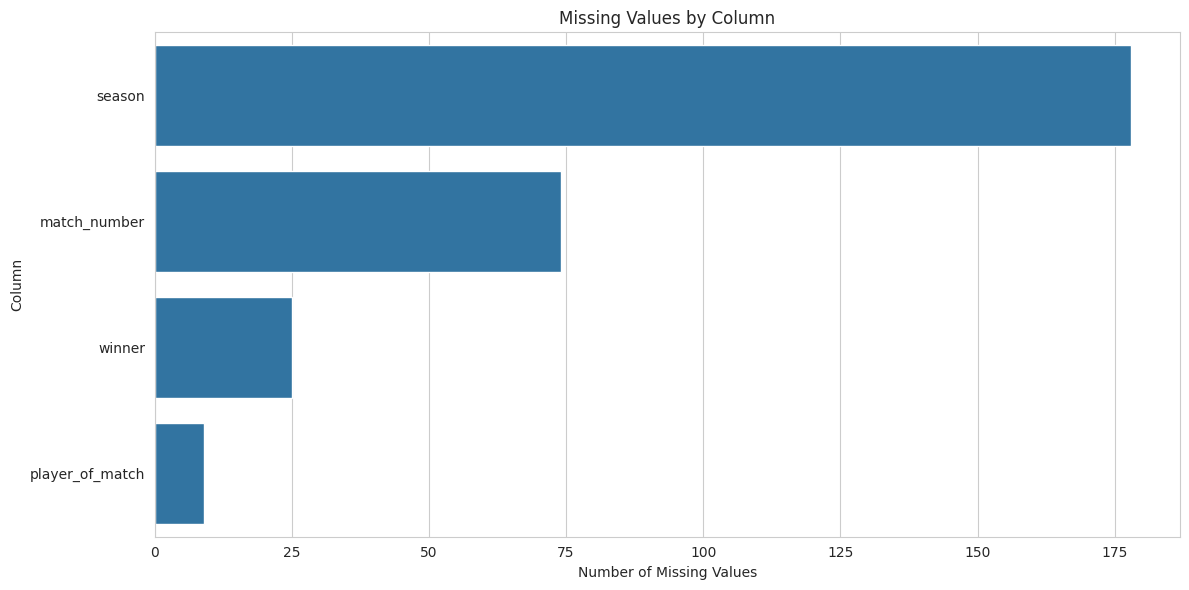

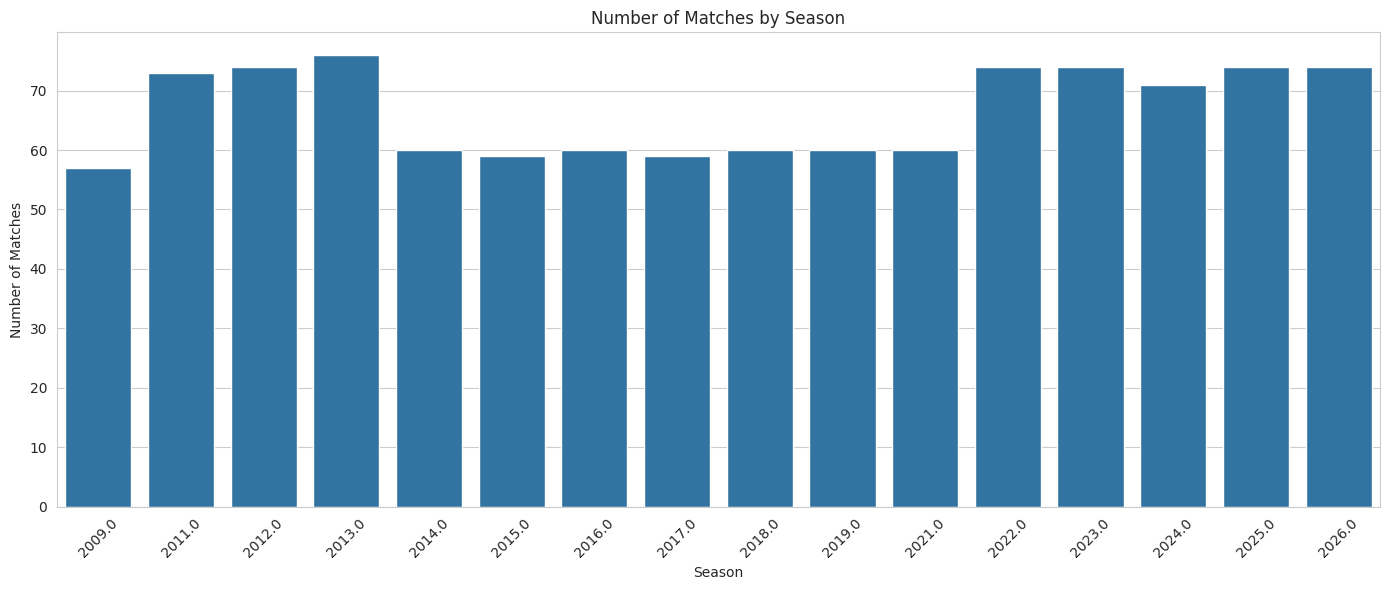

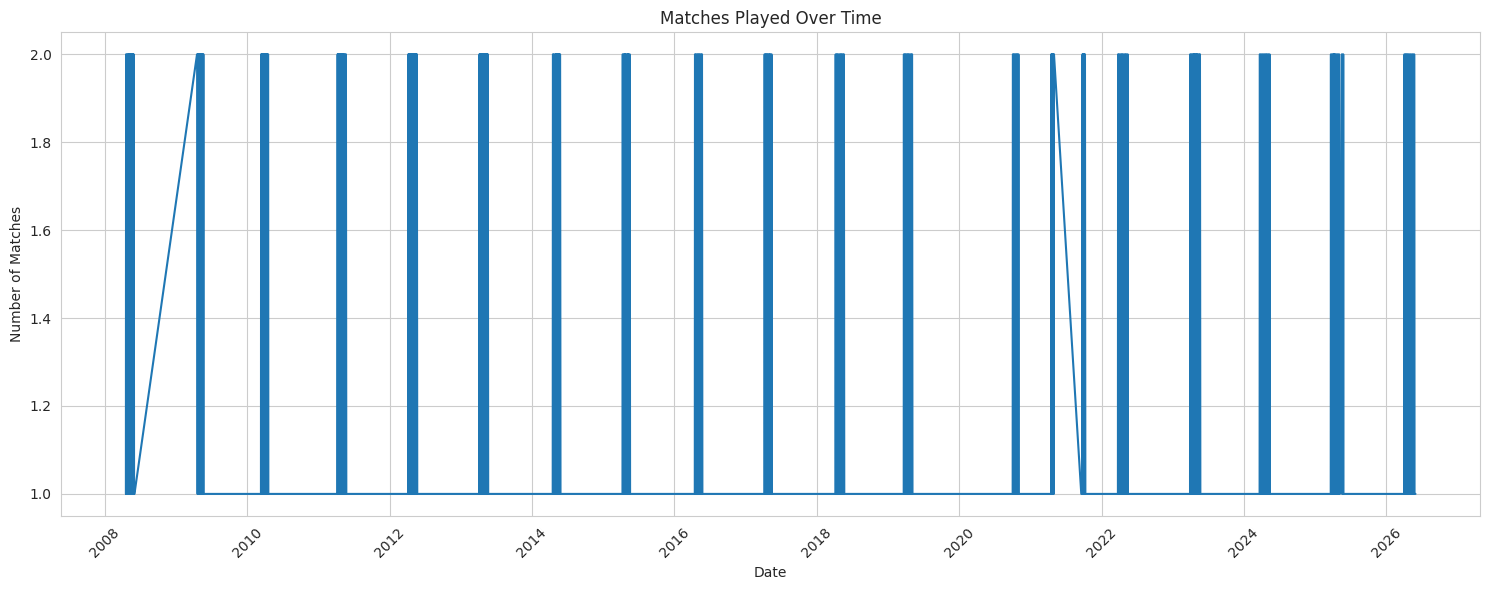

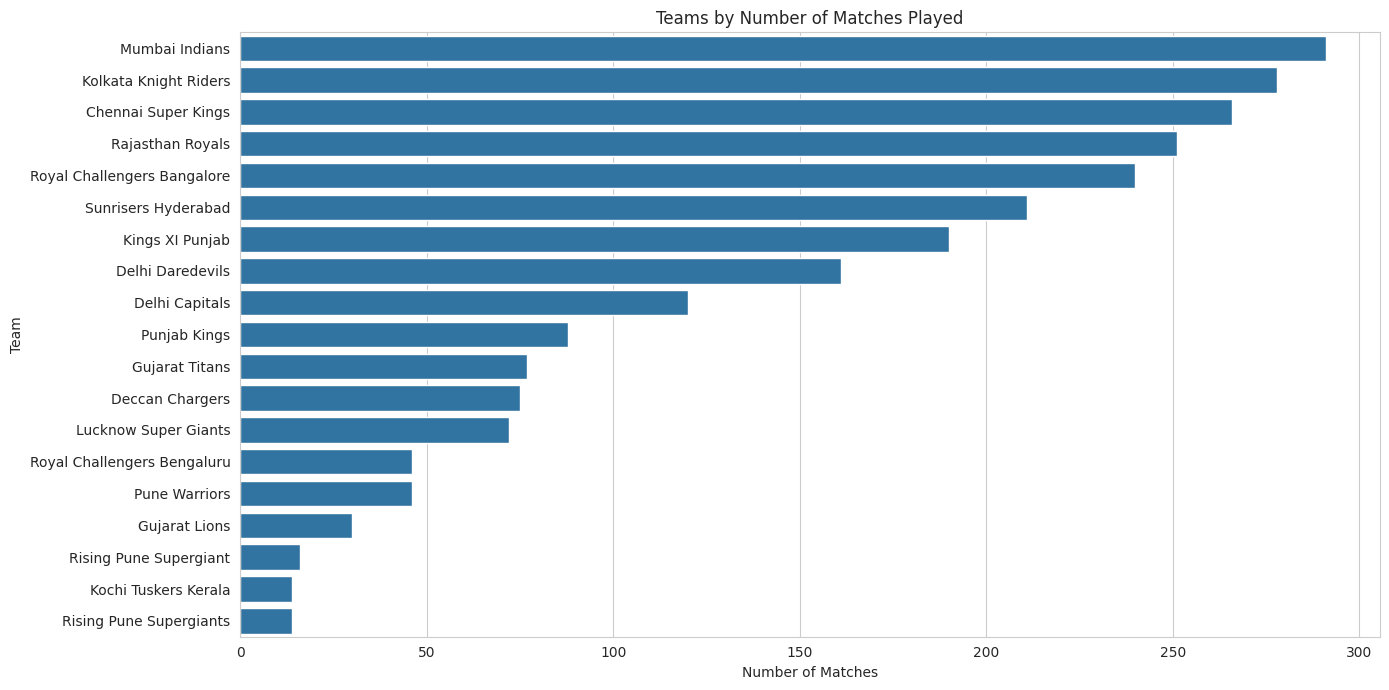

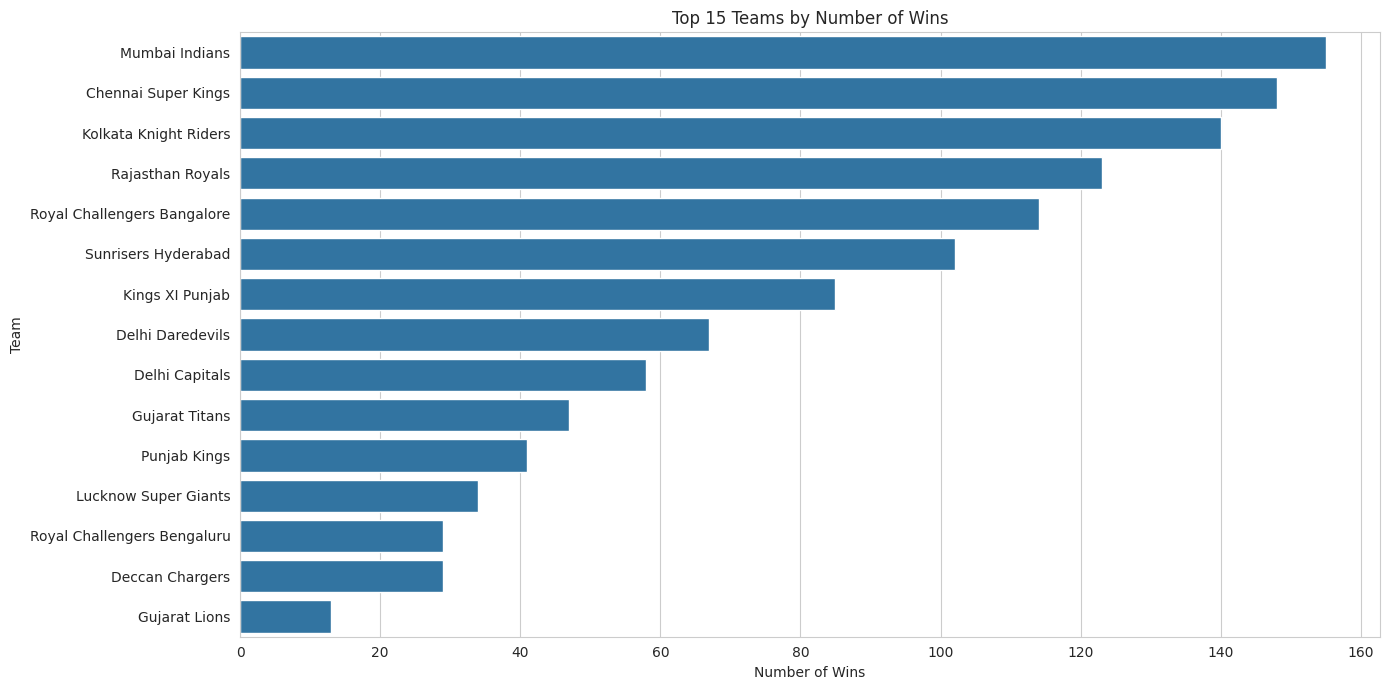

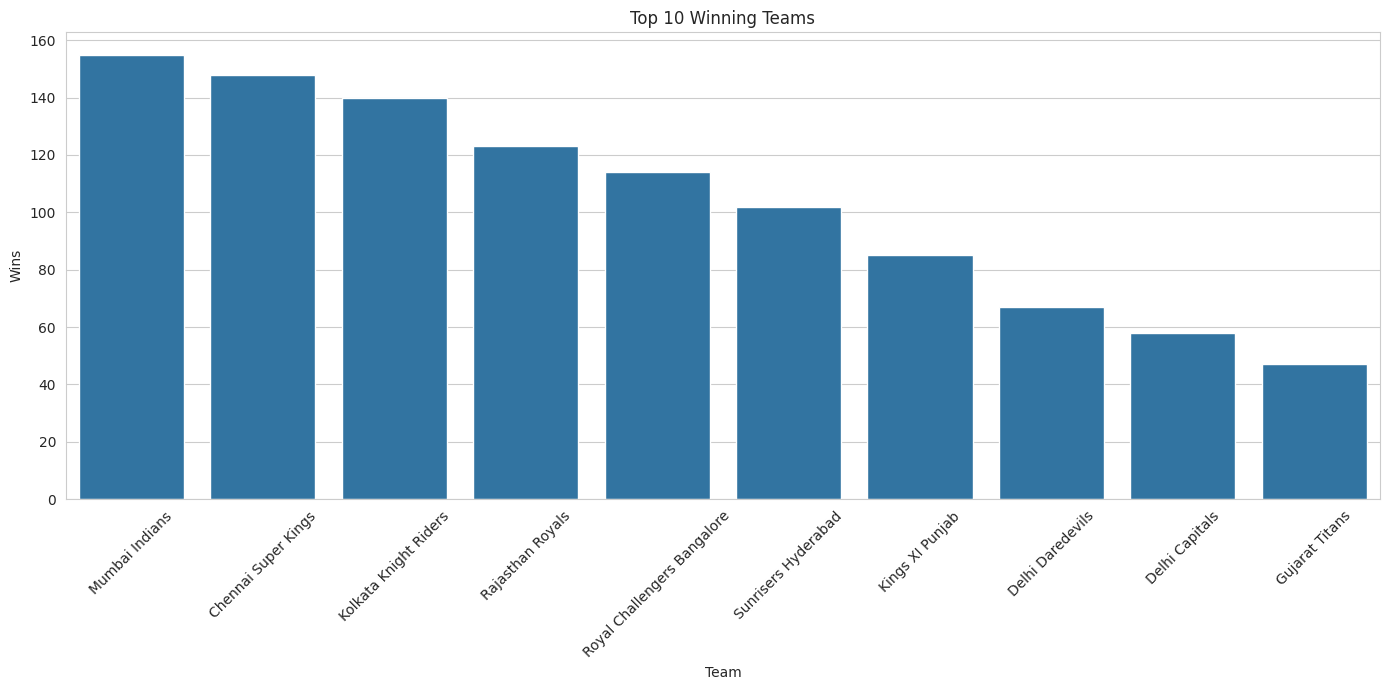

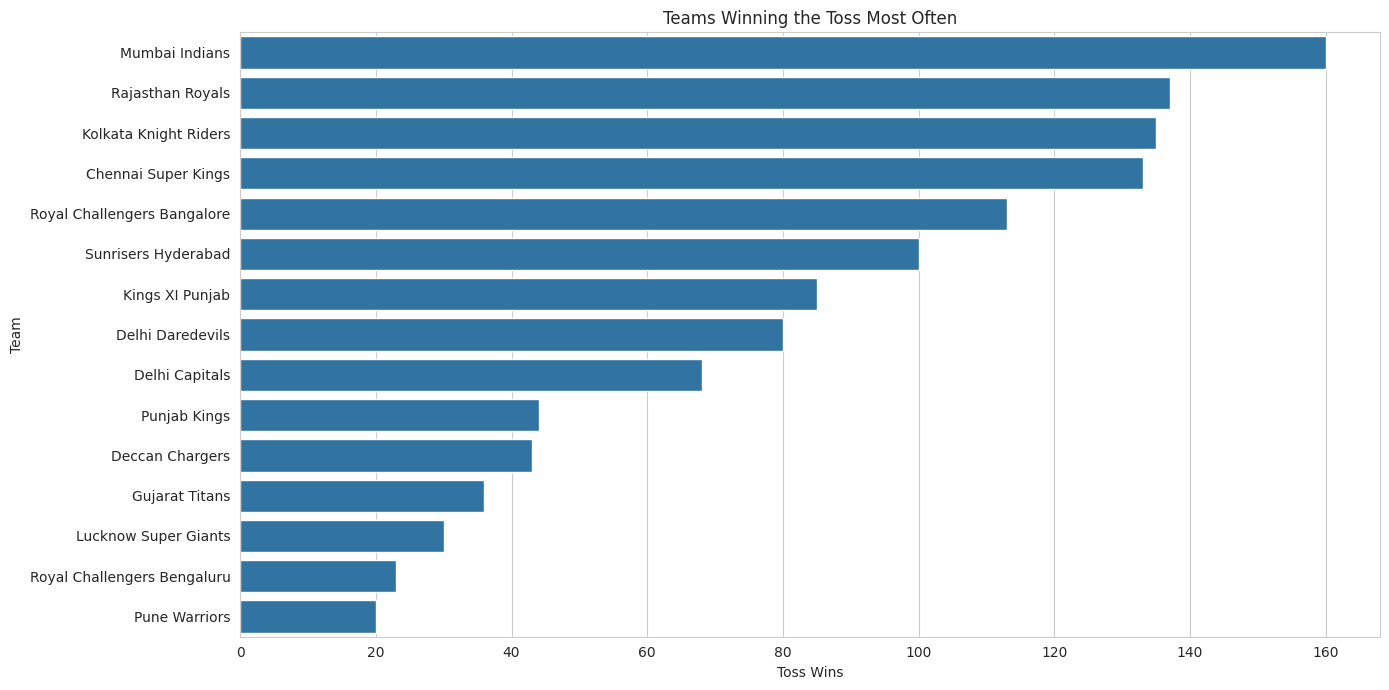

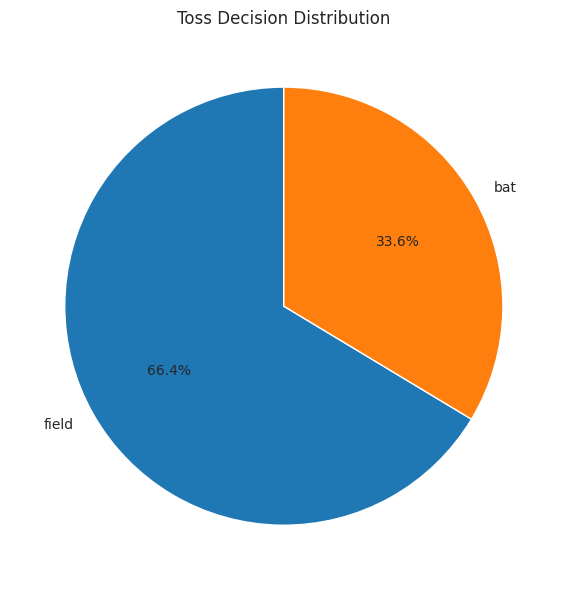

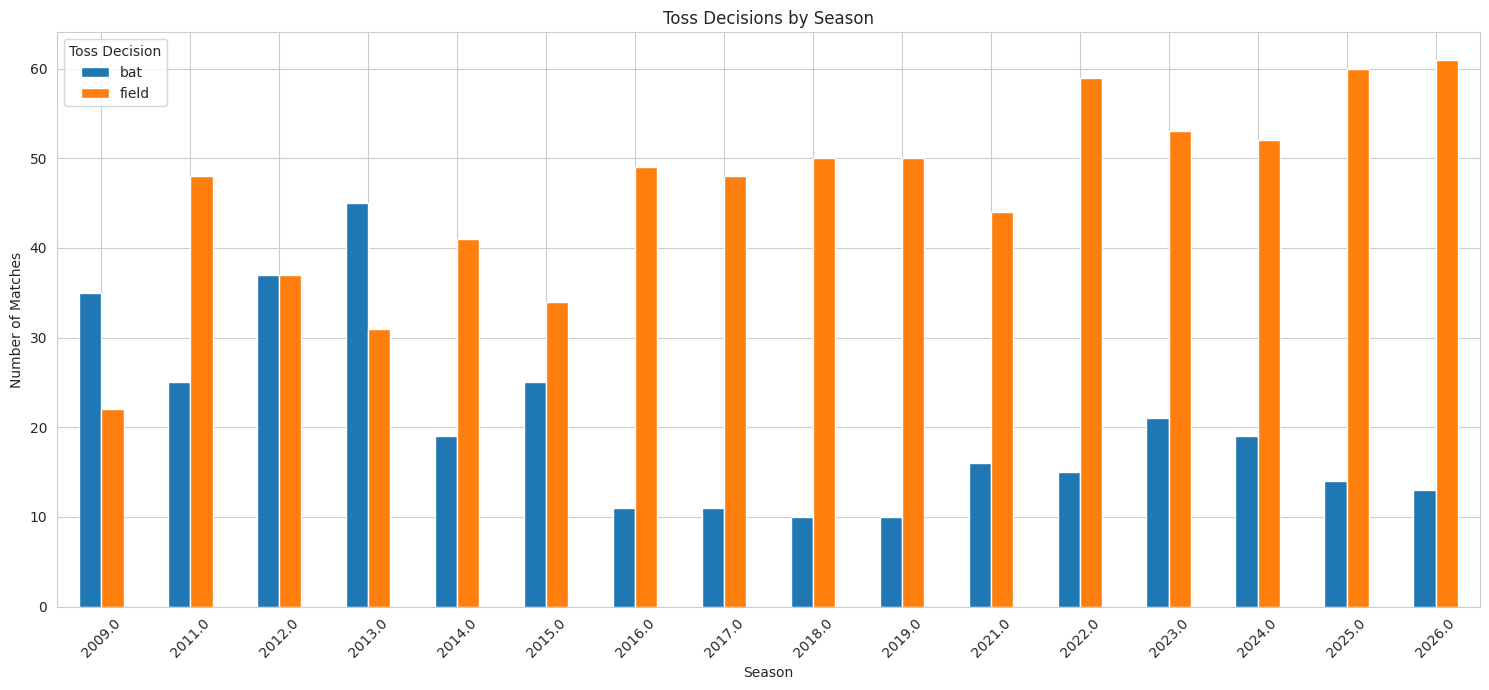

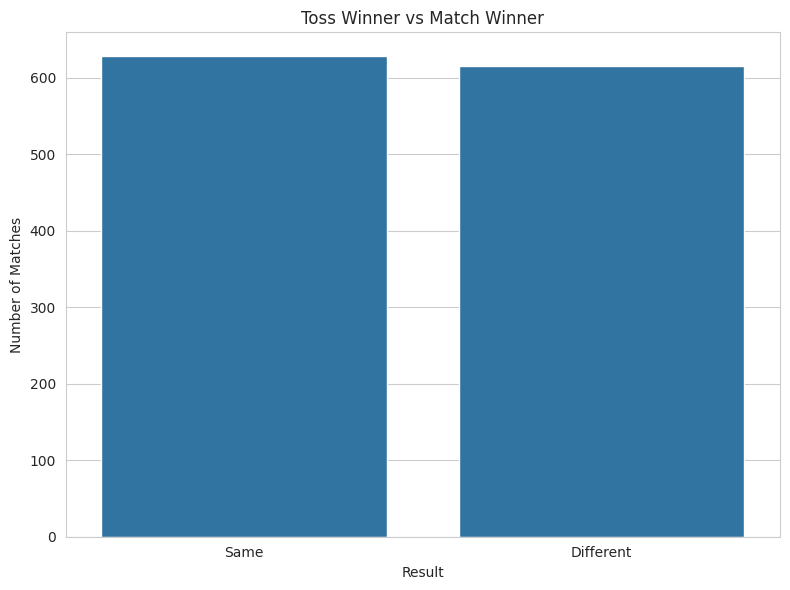


Toss Winner Also Won Match: 50.52%


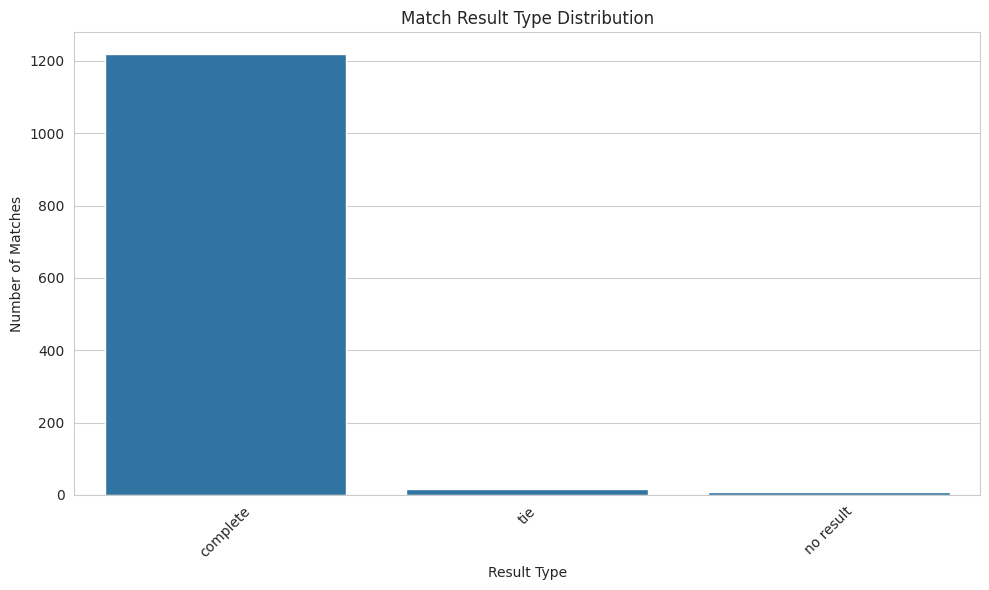

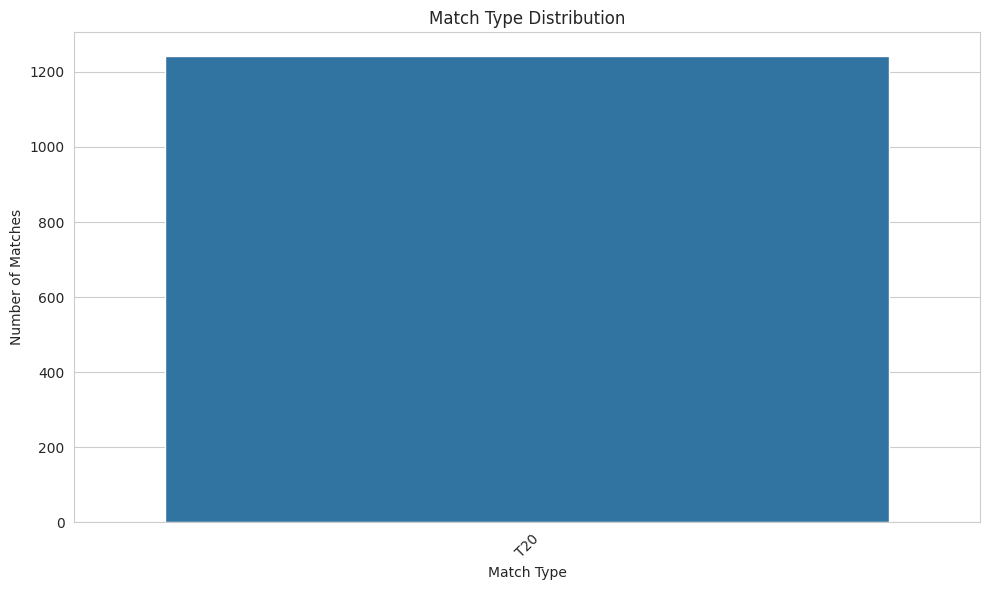

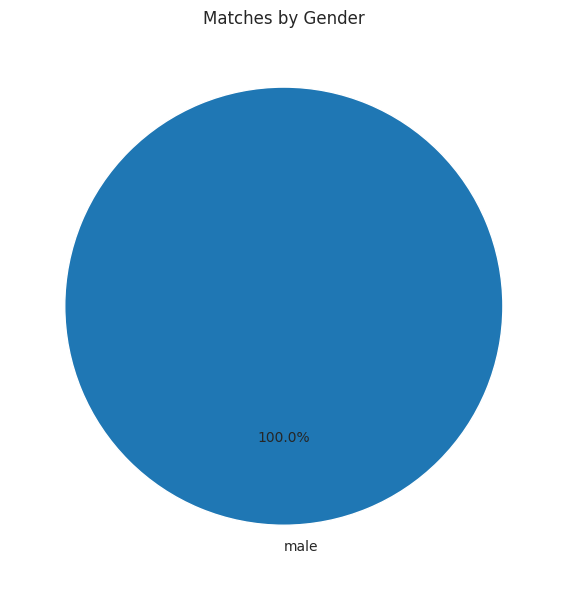

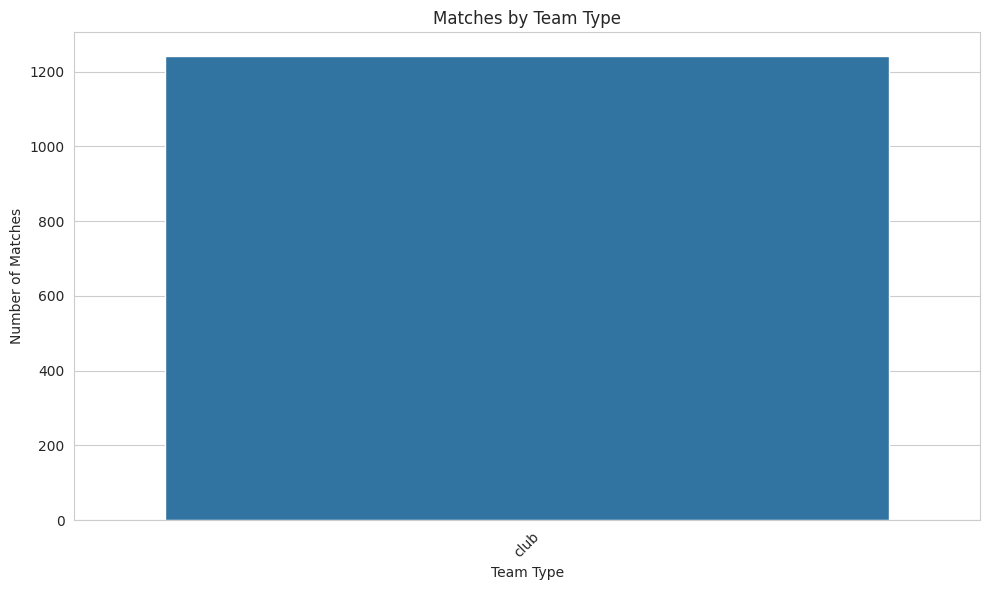

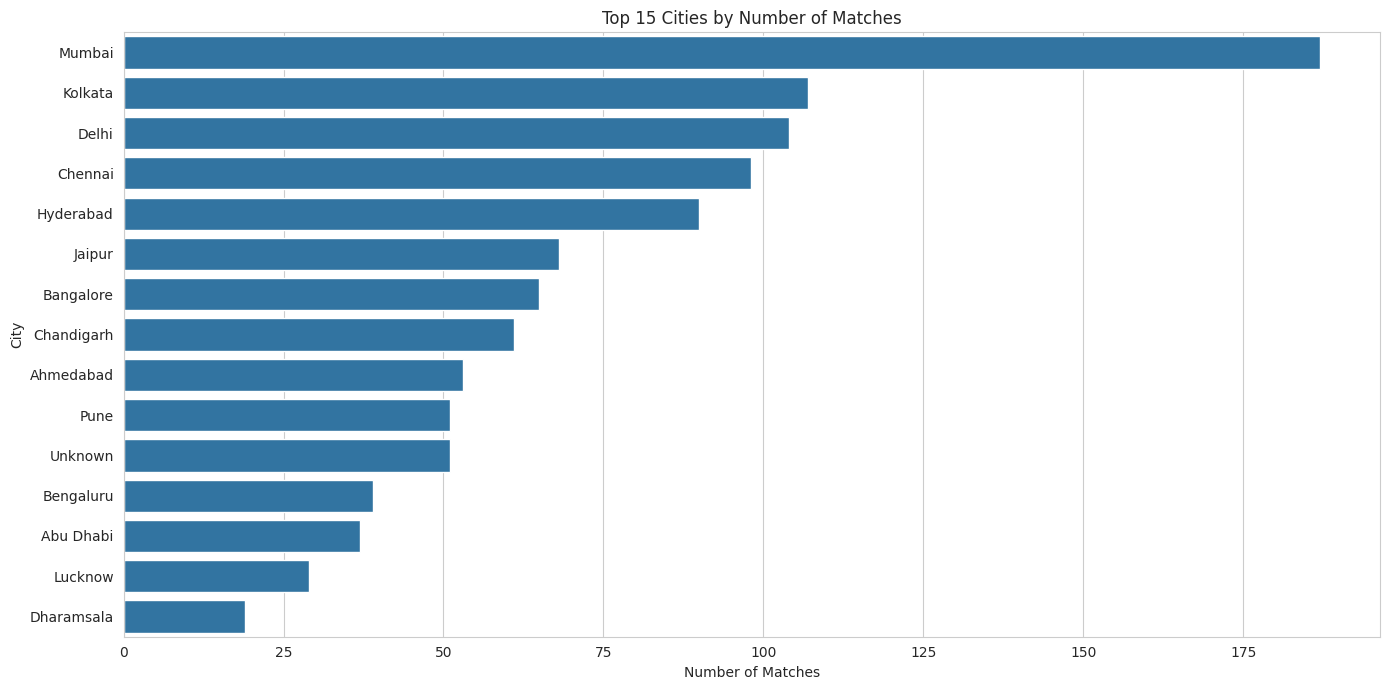

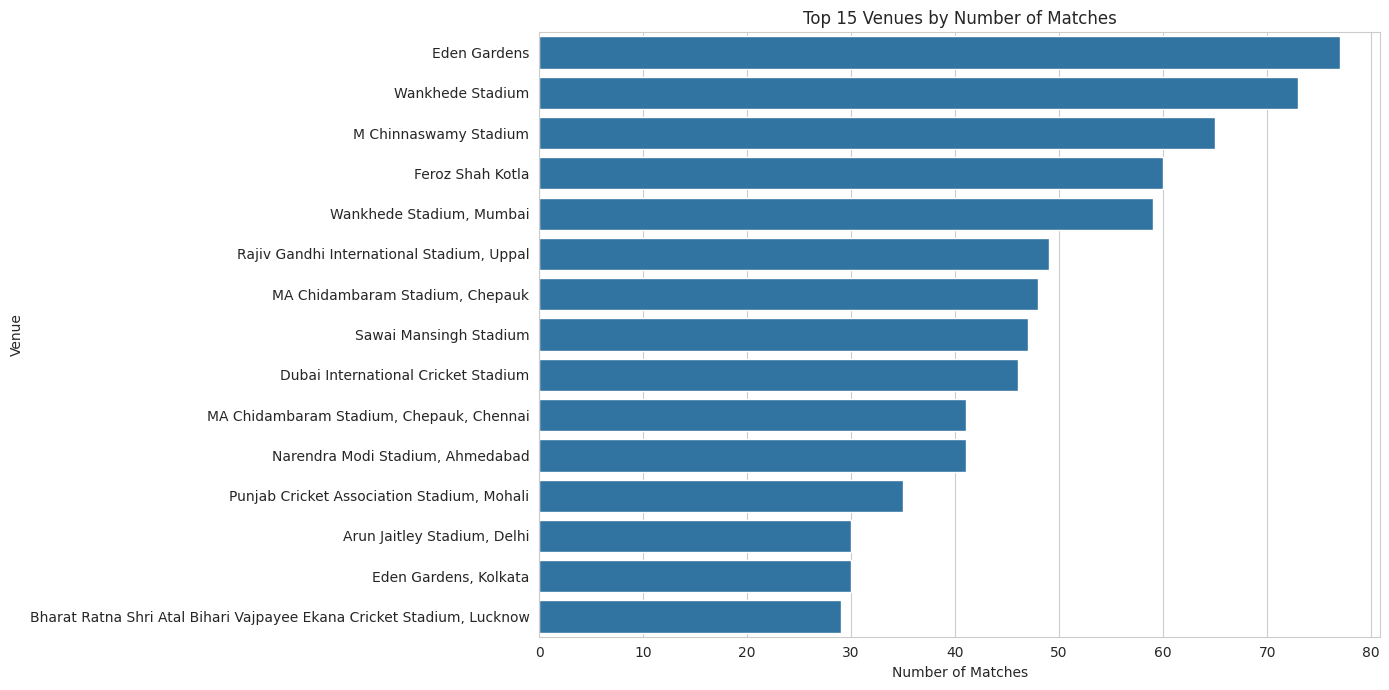

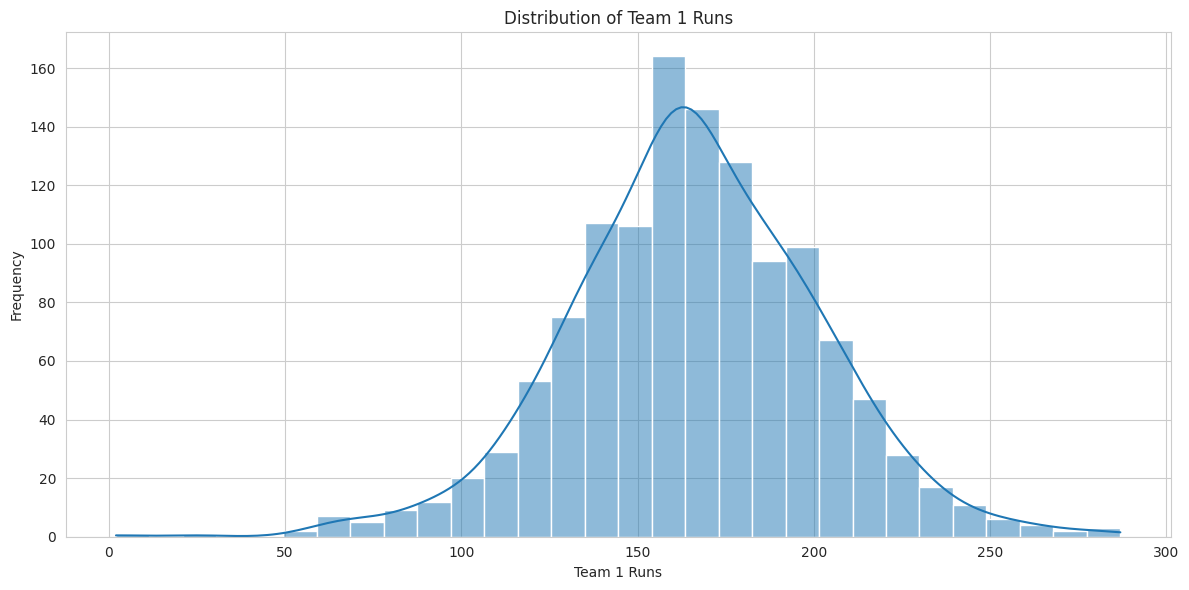

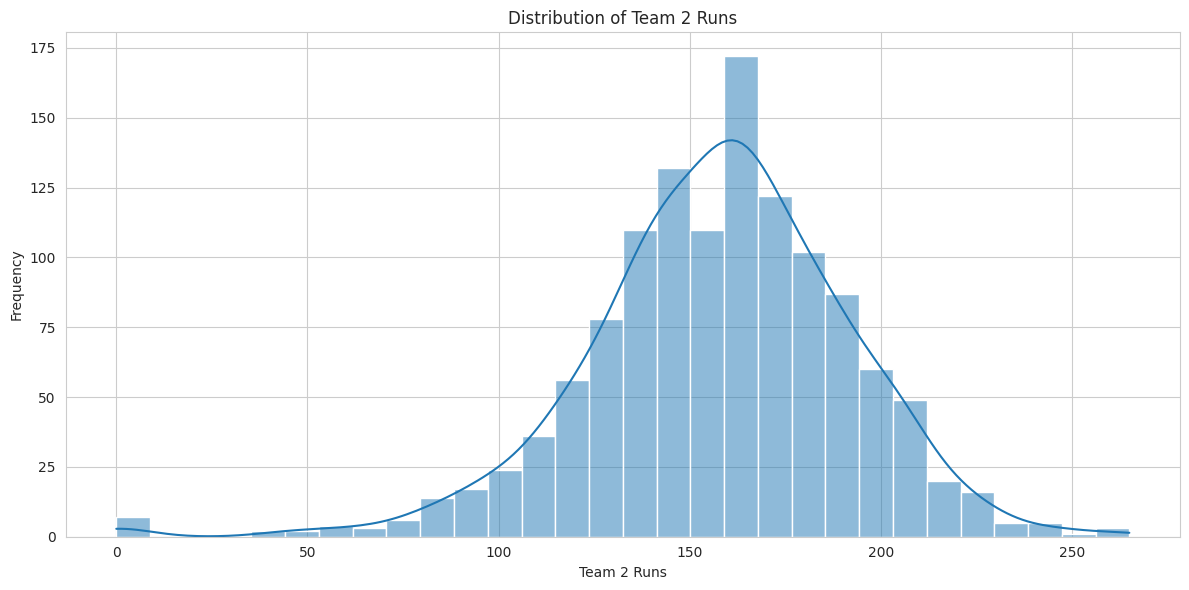

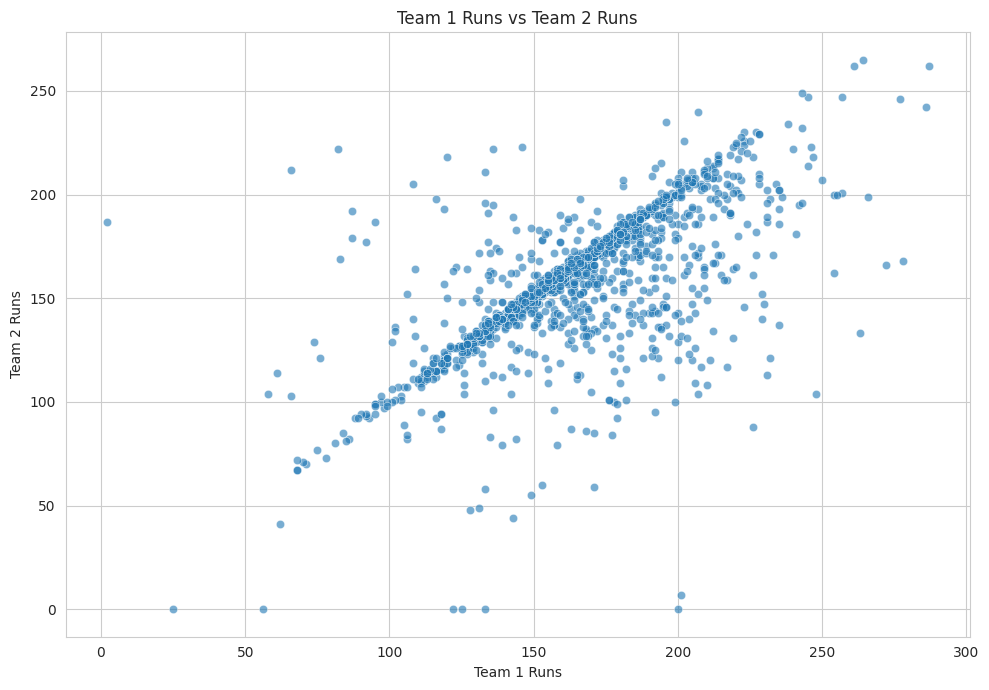

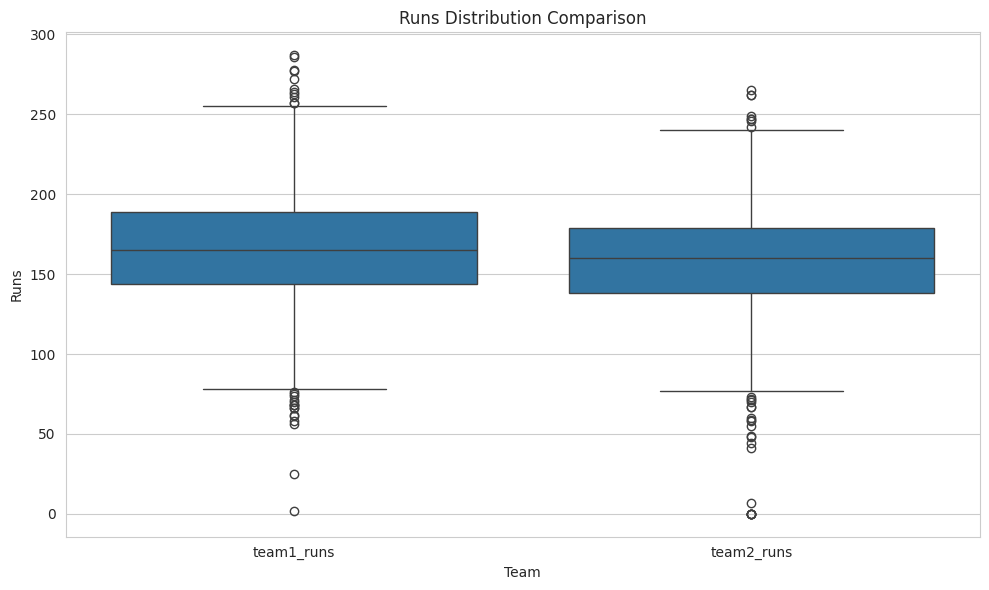

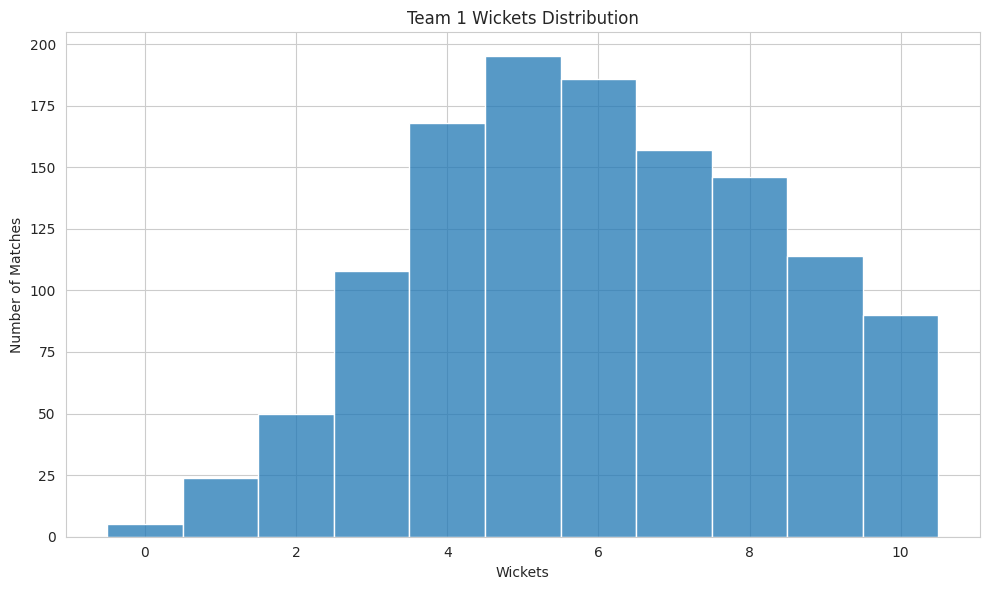

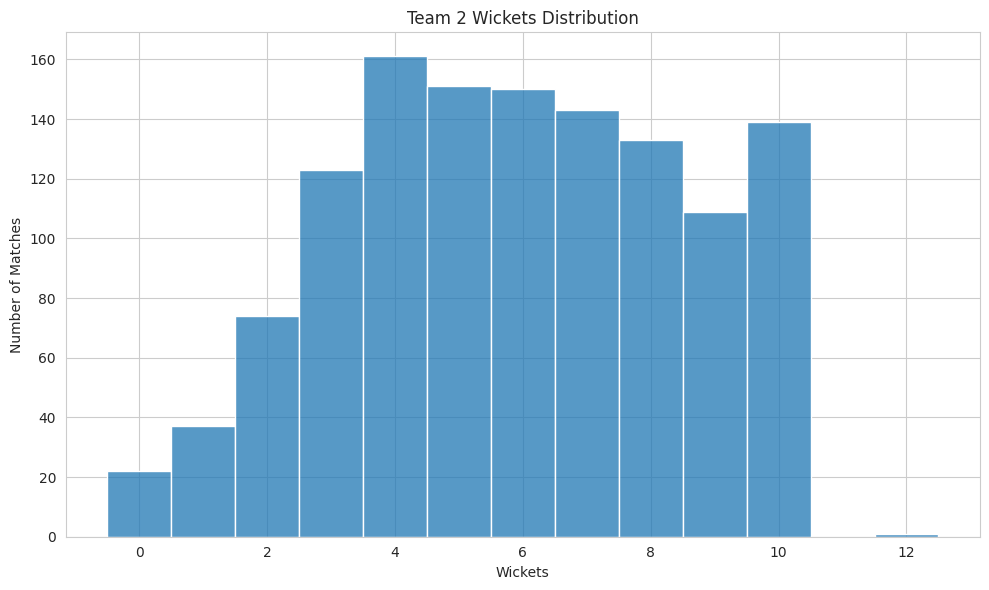

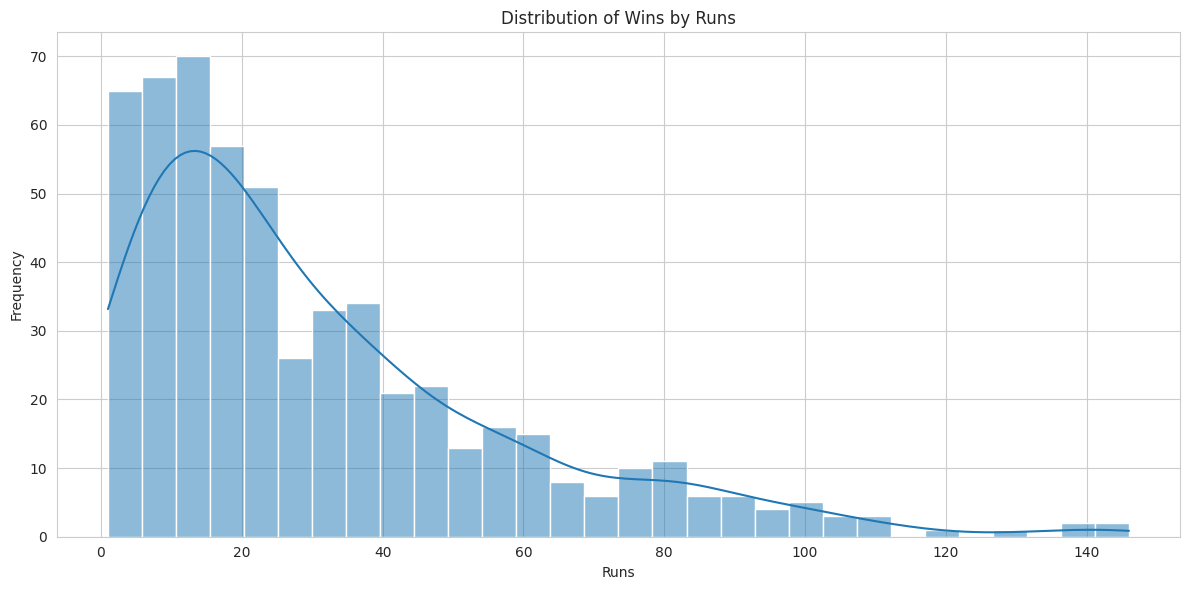

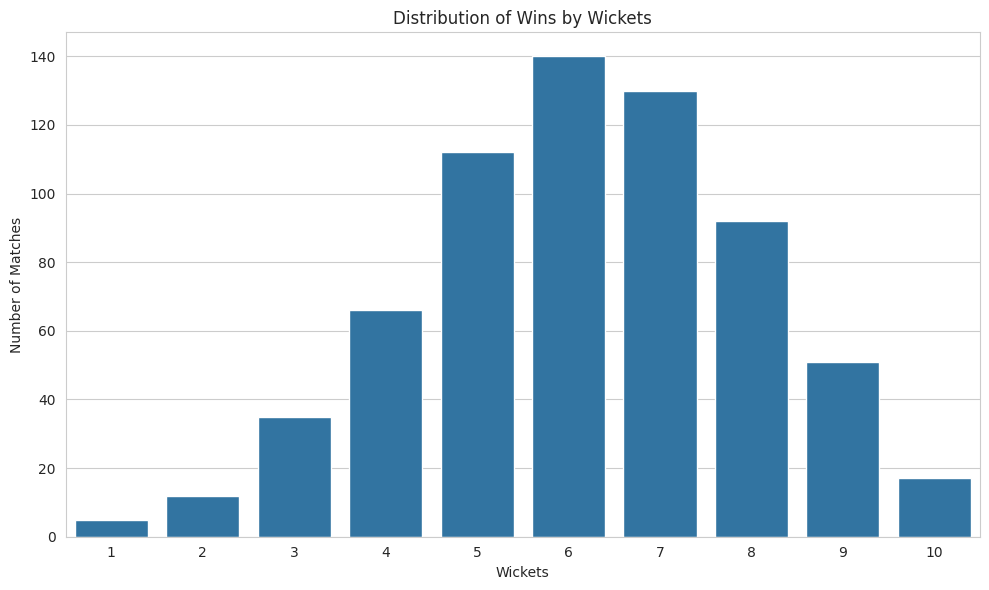

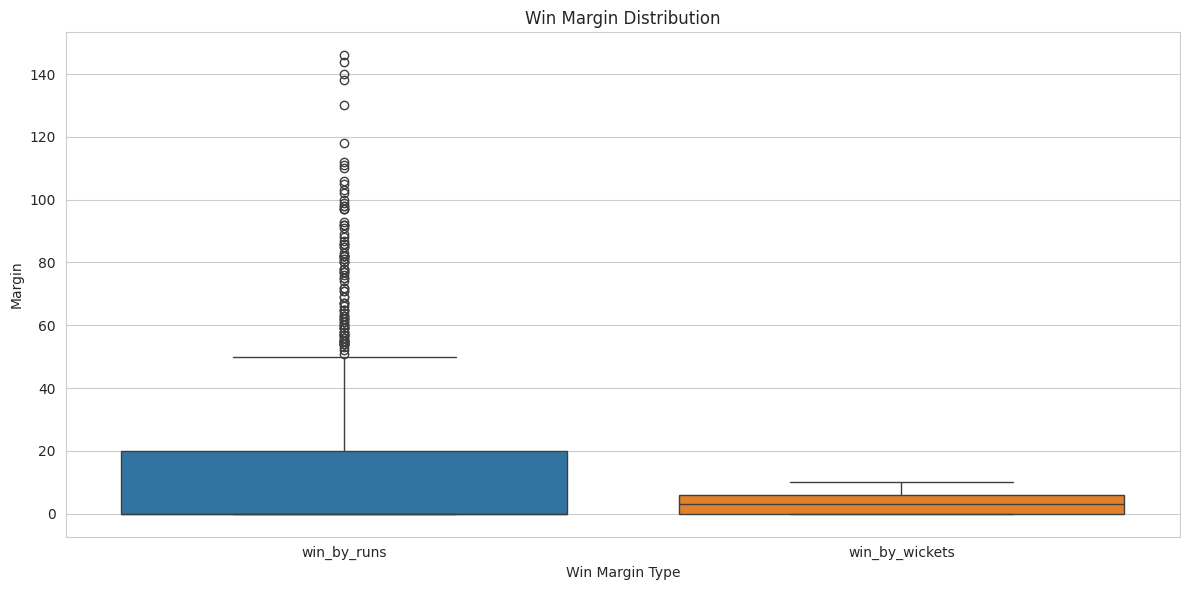

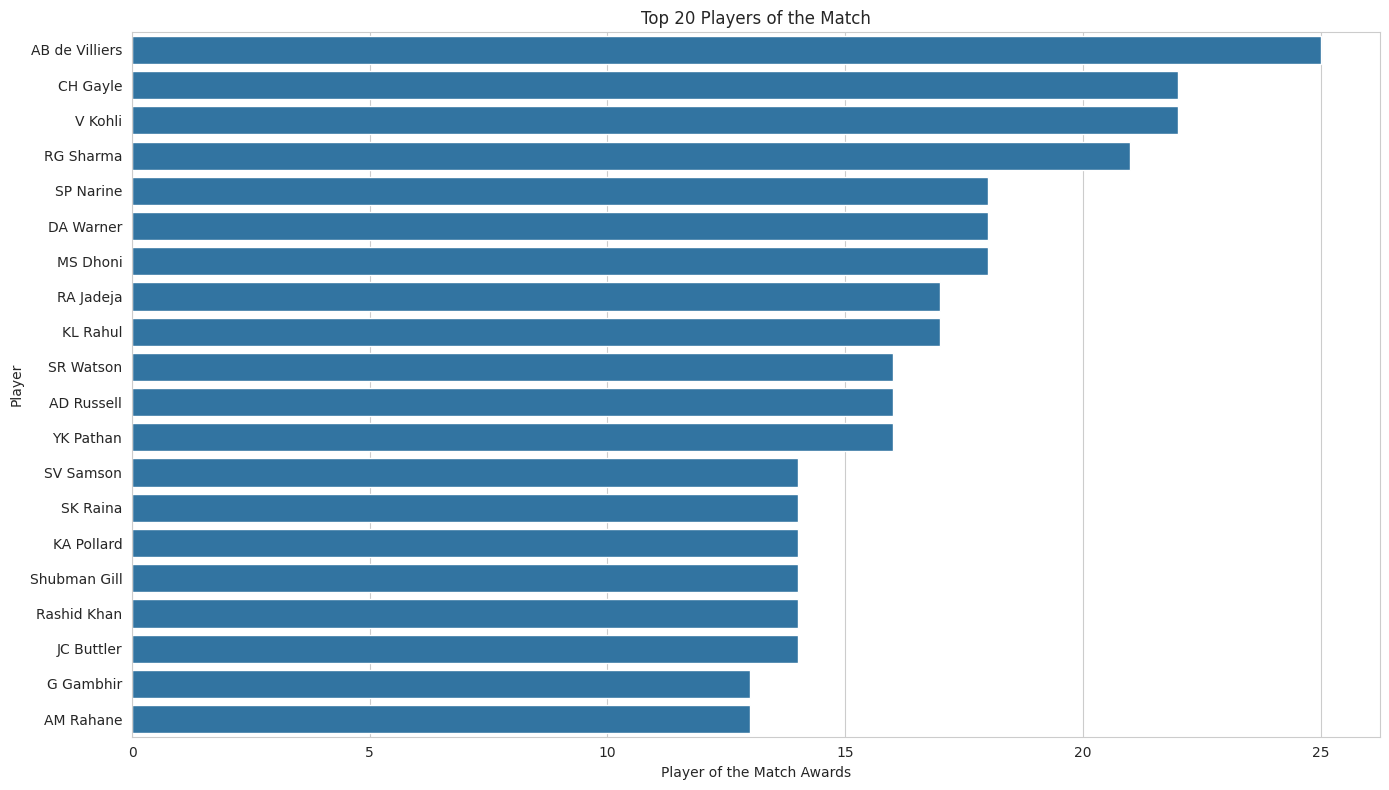

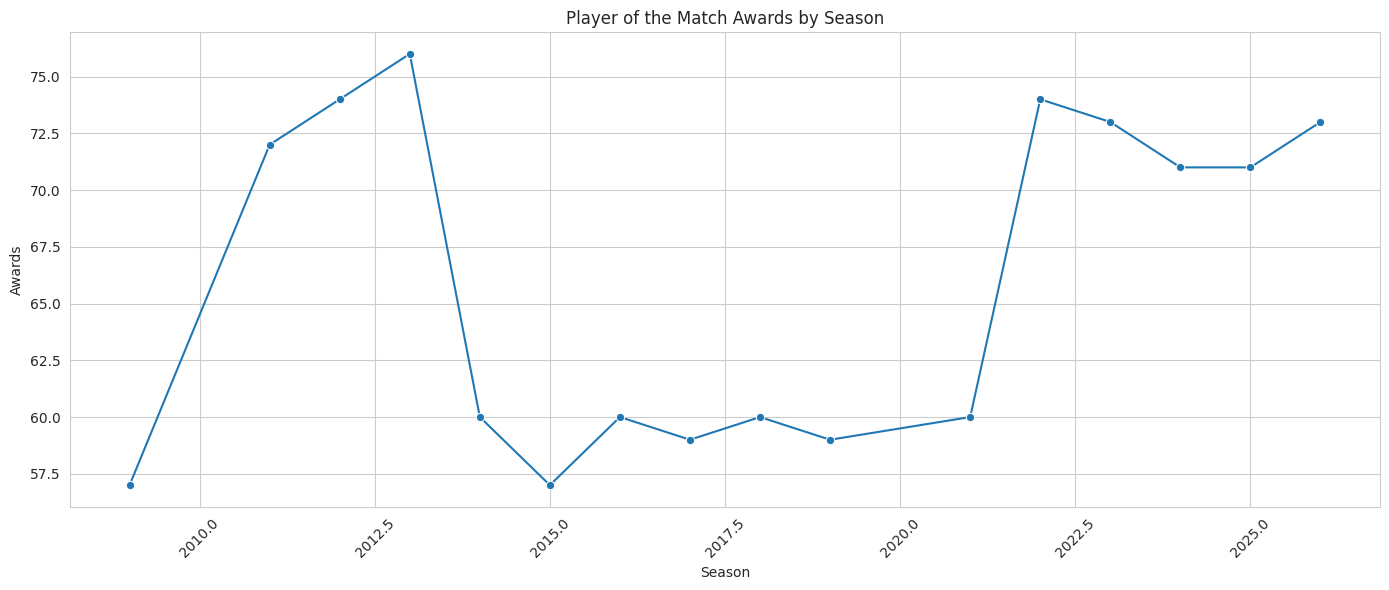

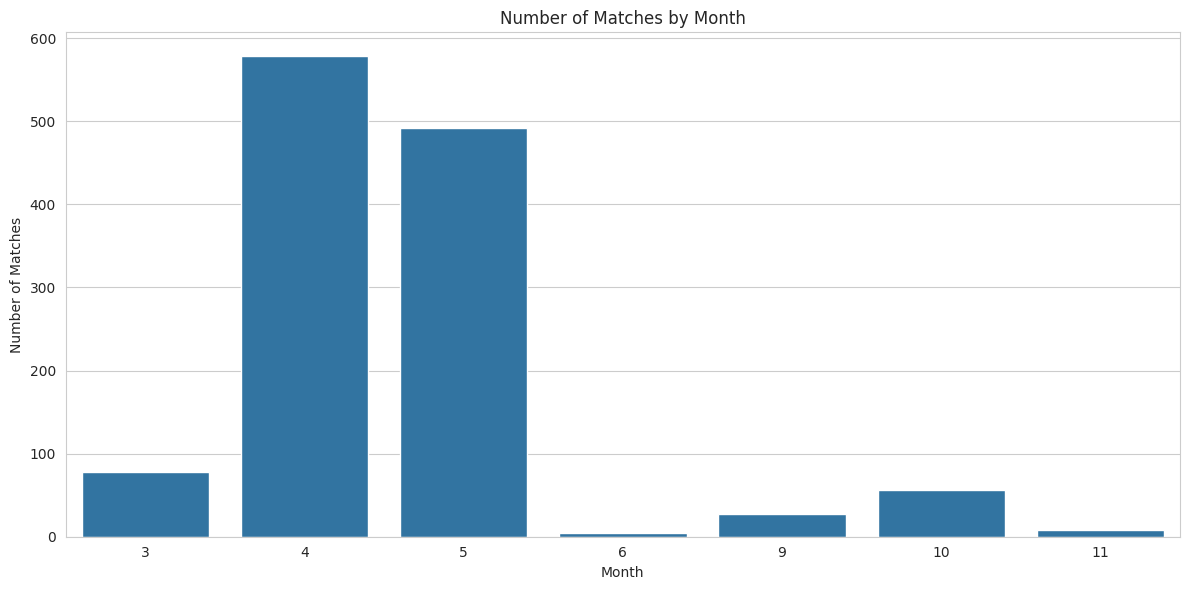

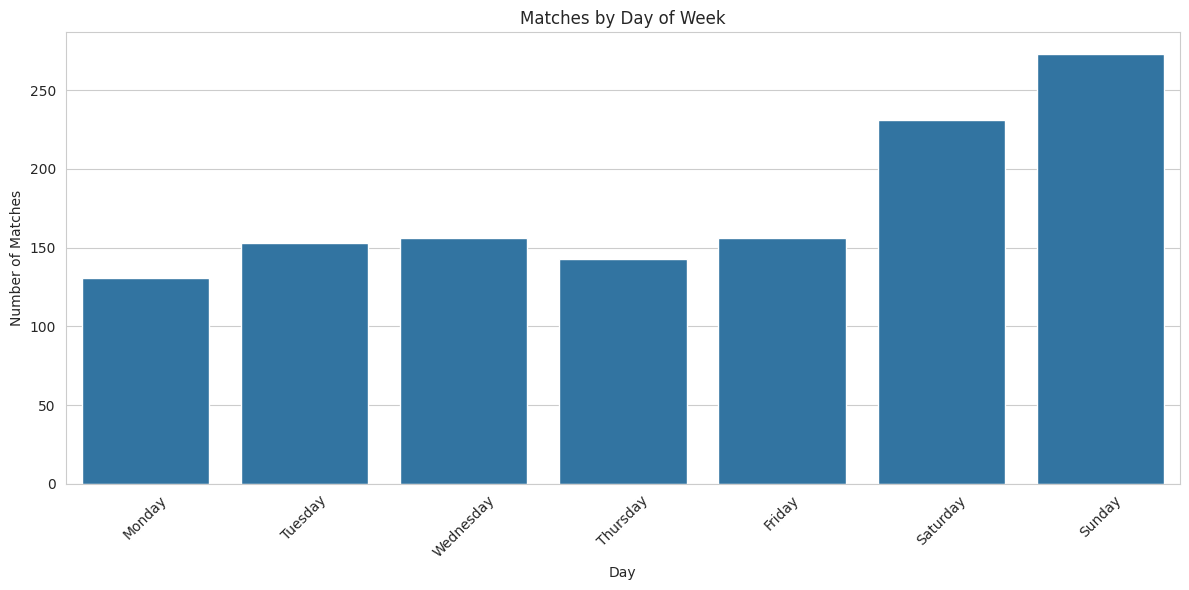

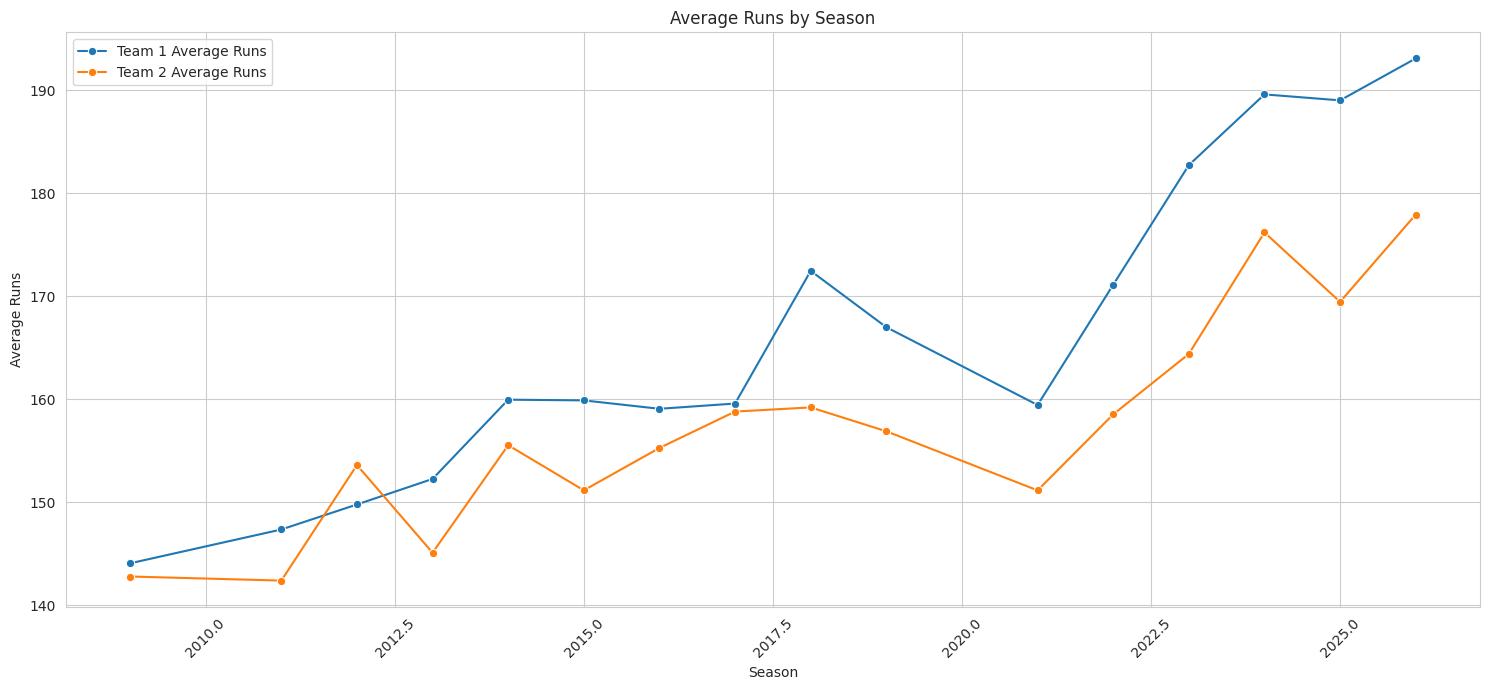

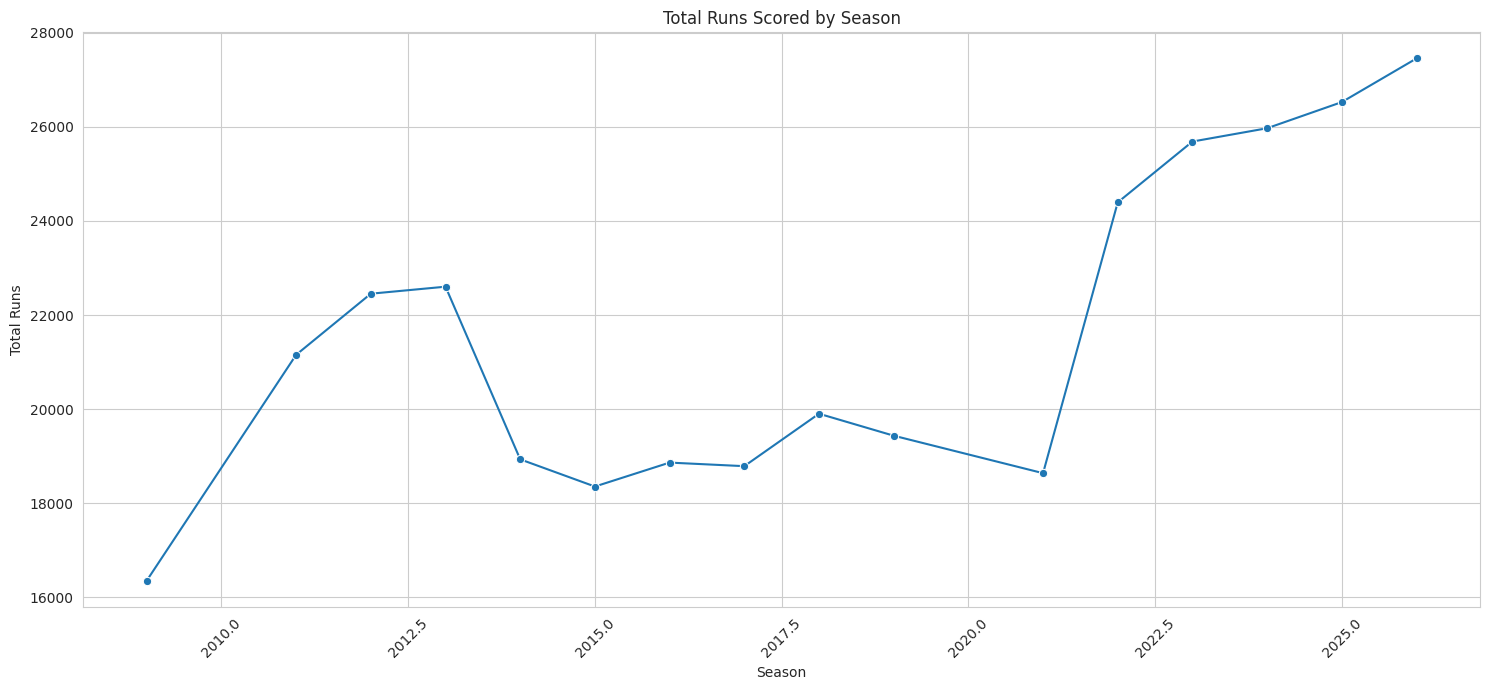

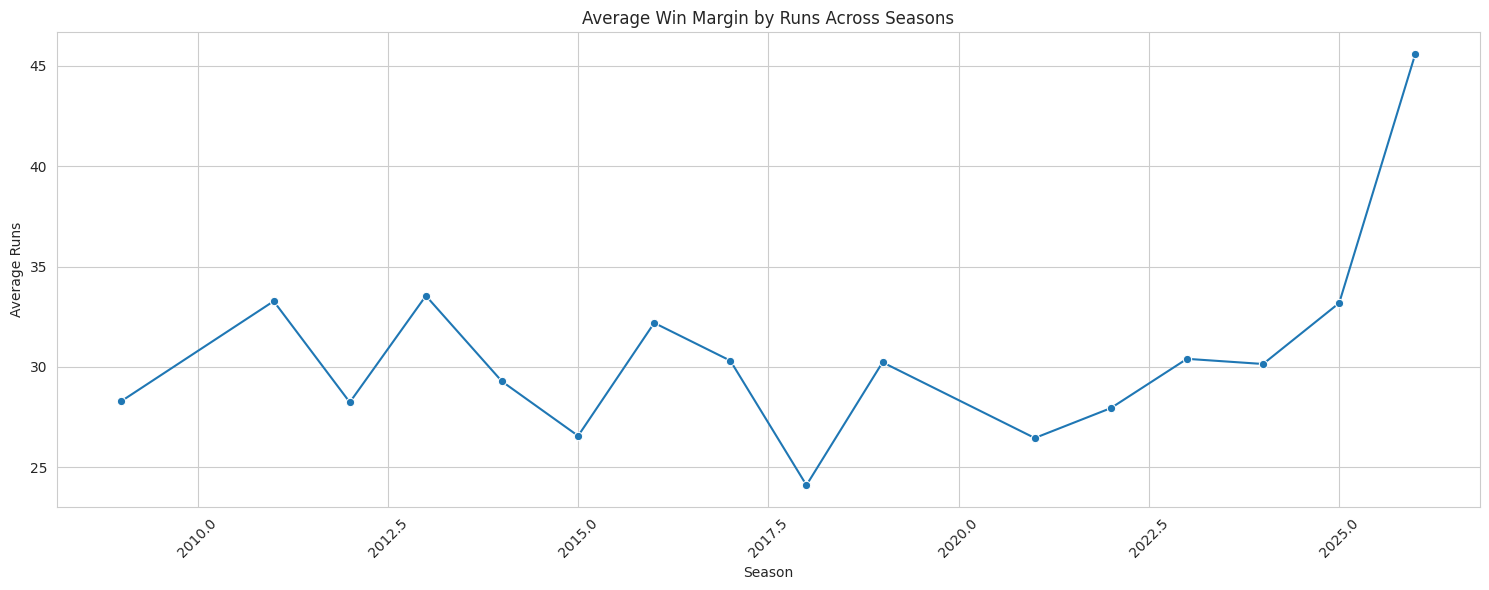

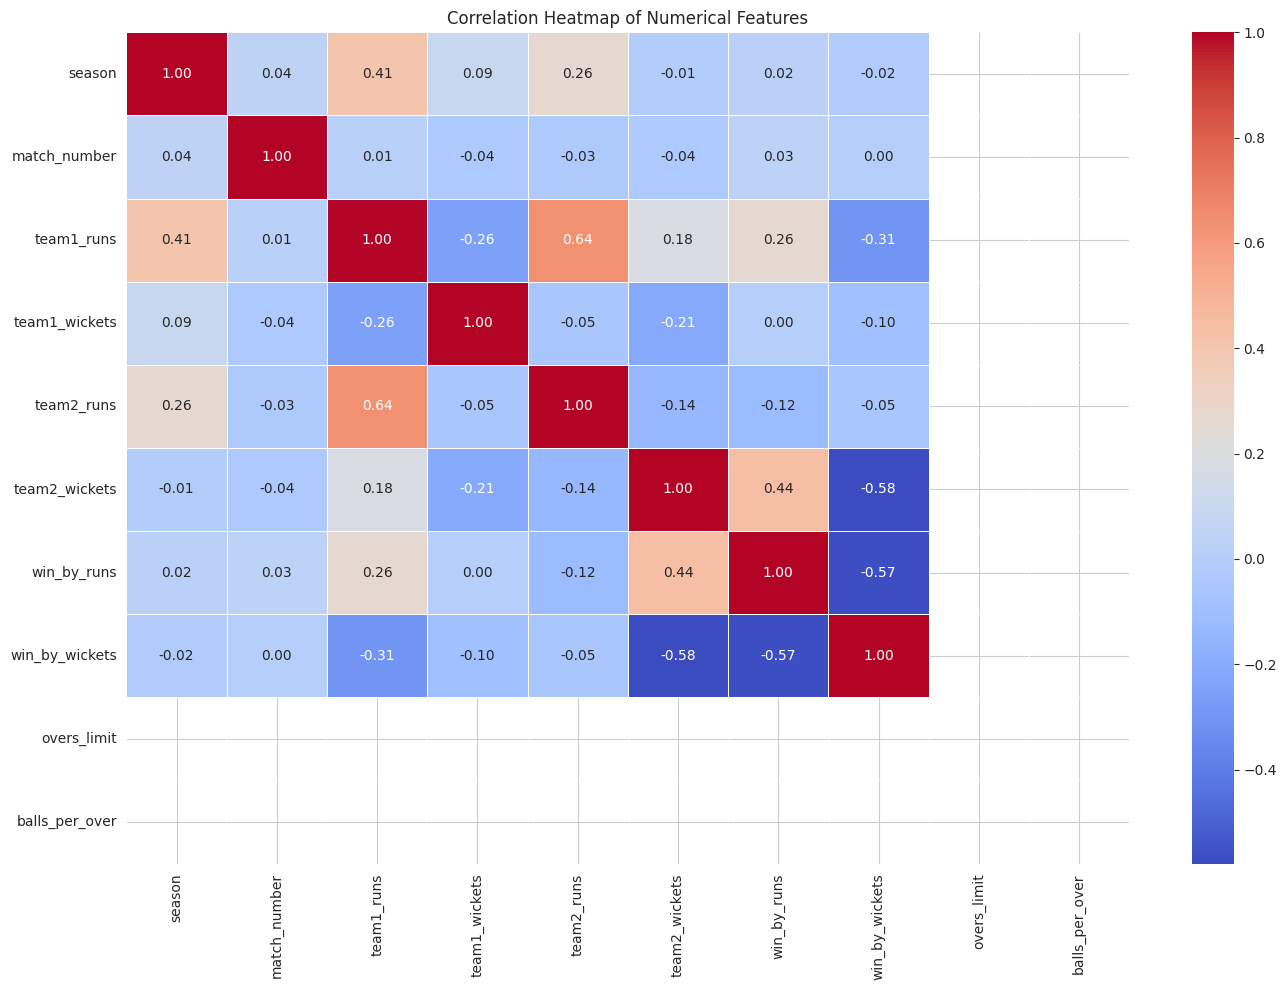

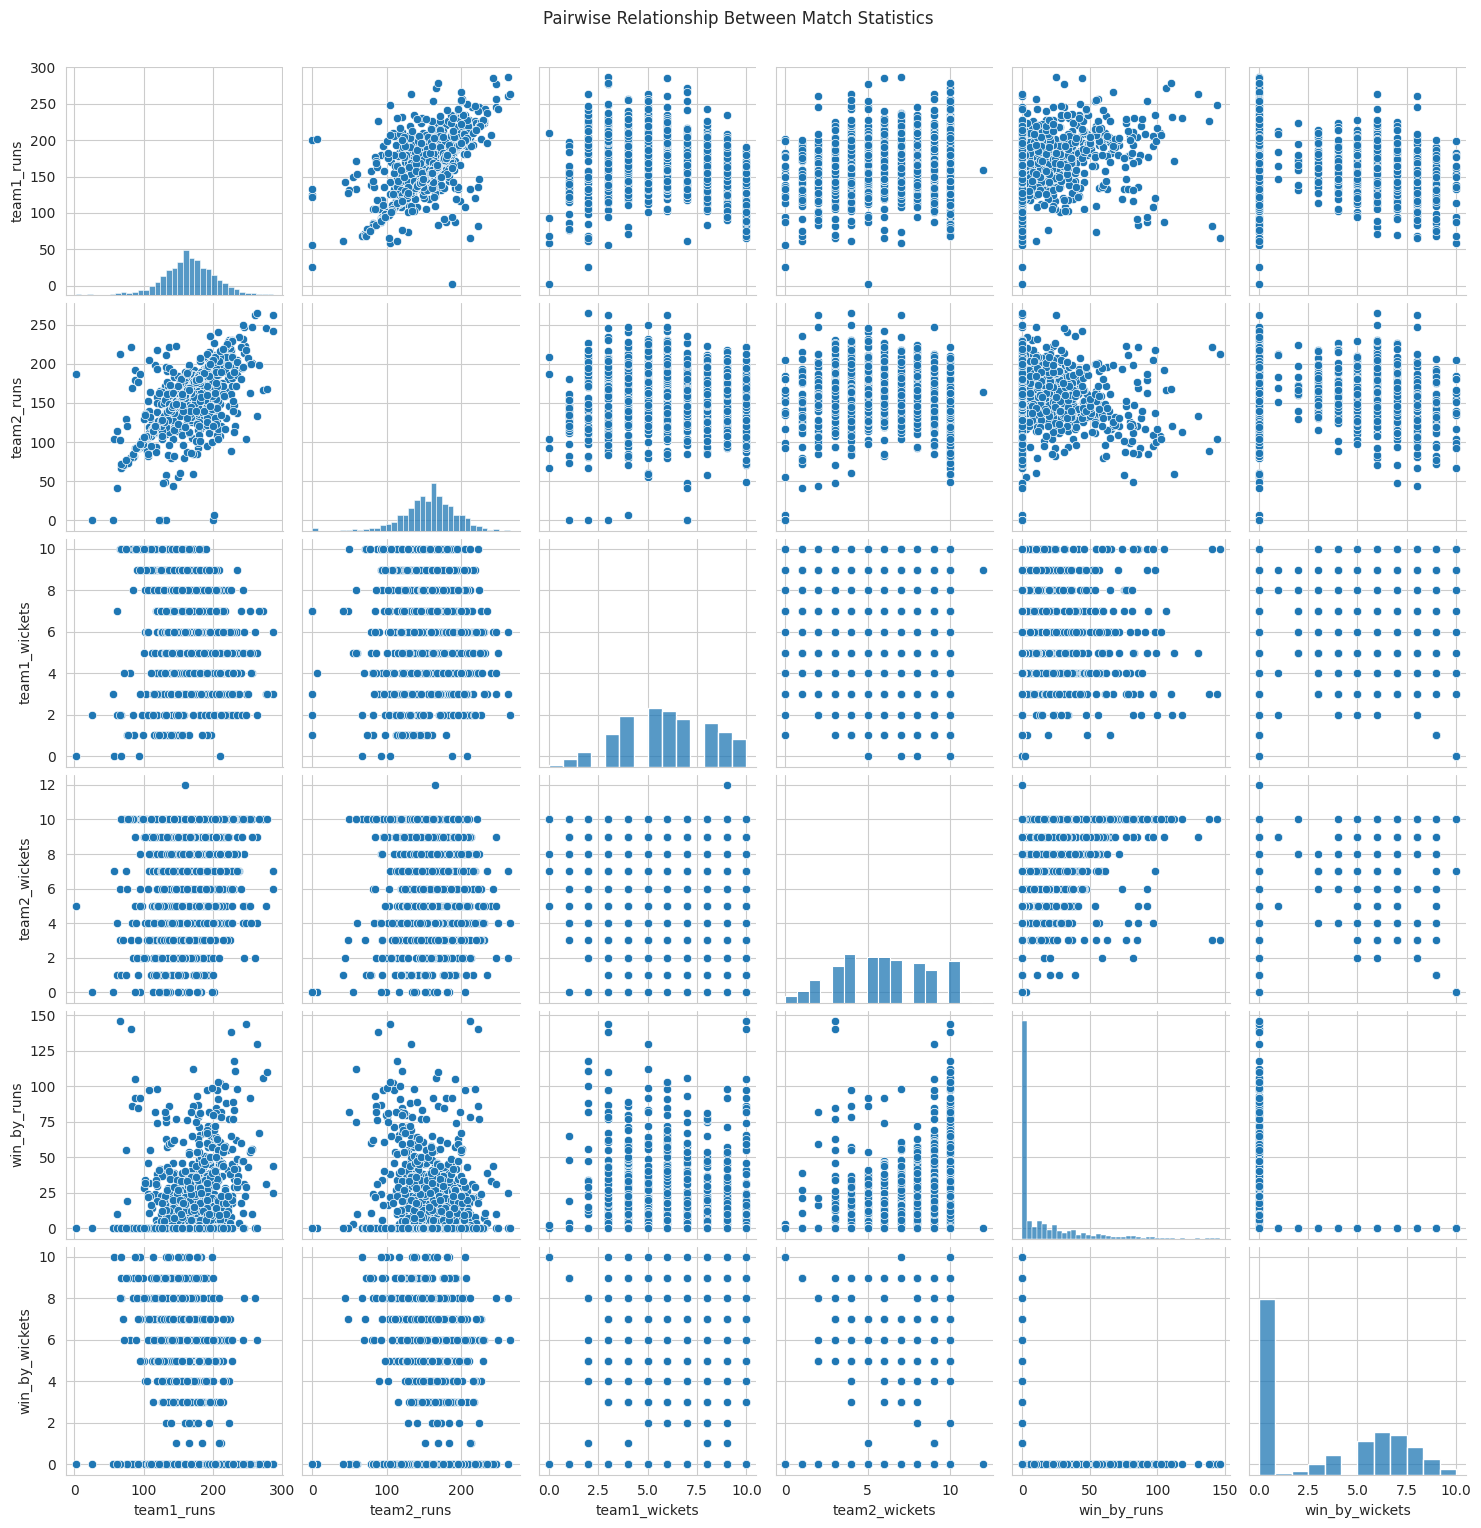

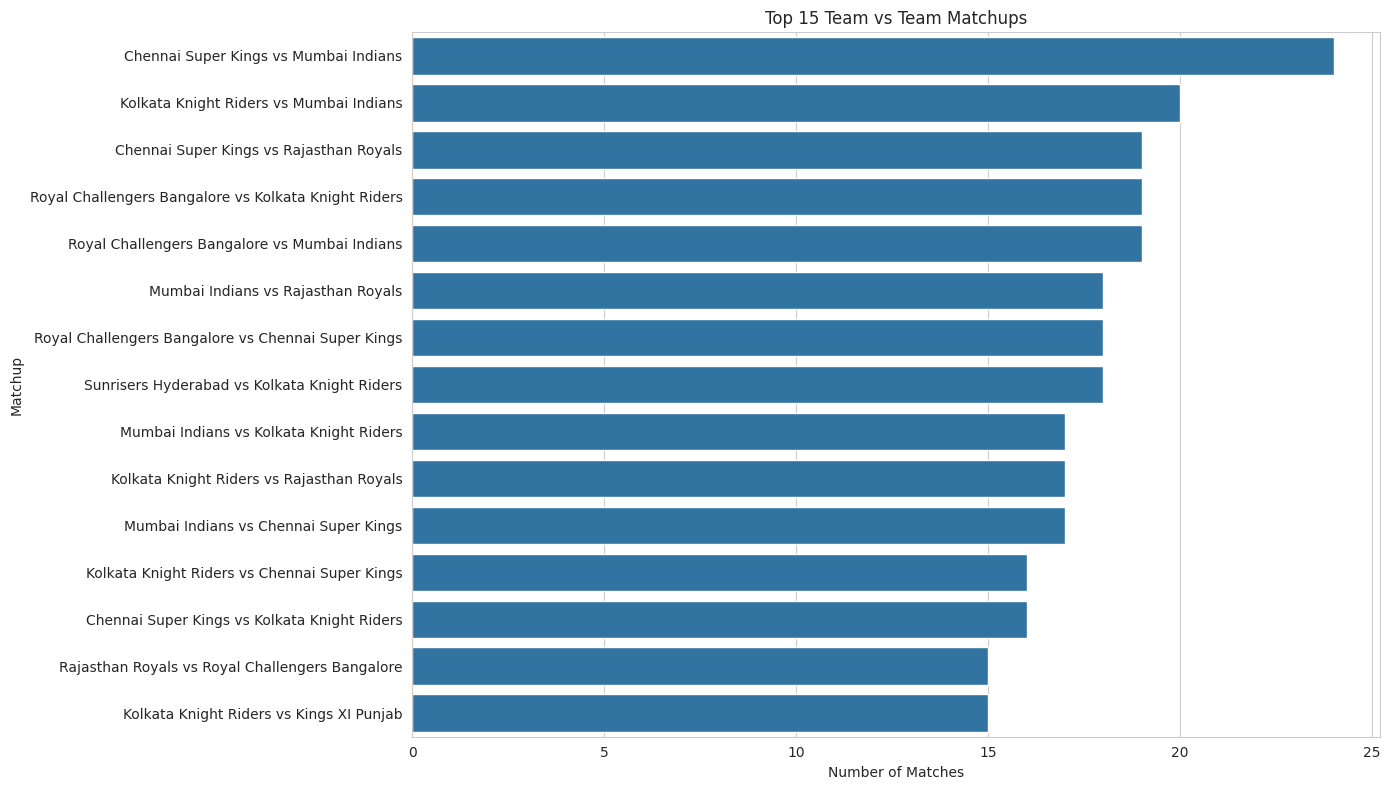

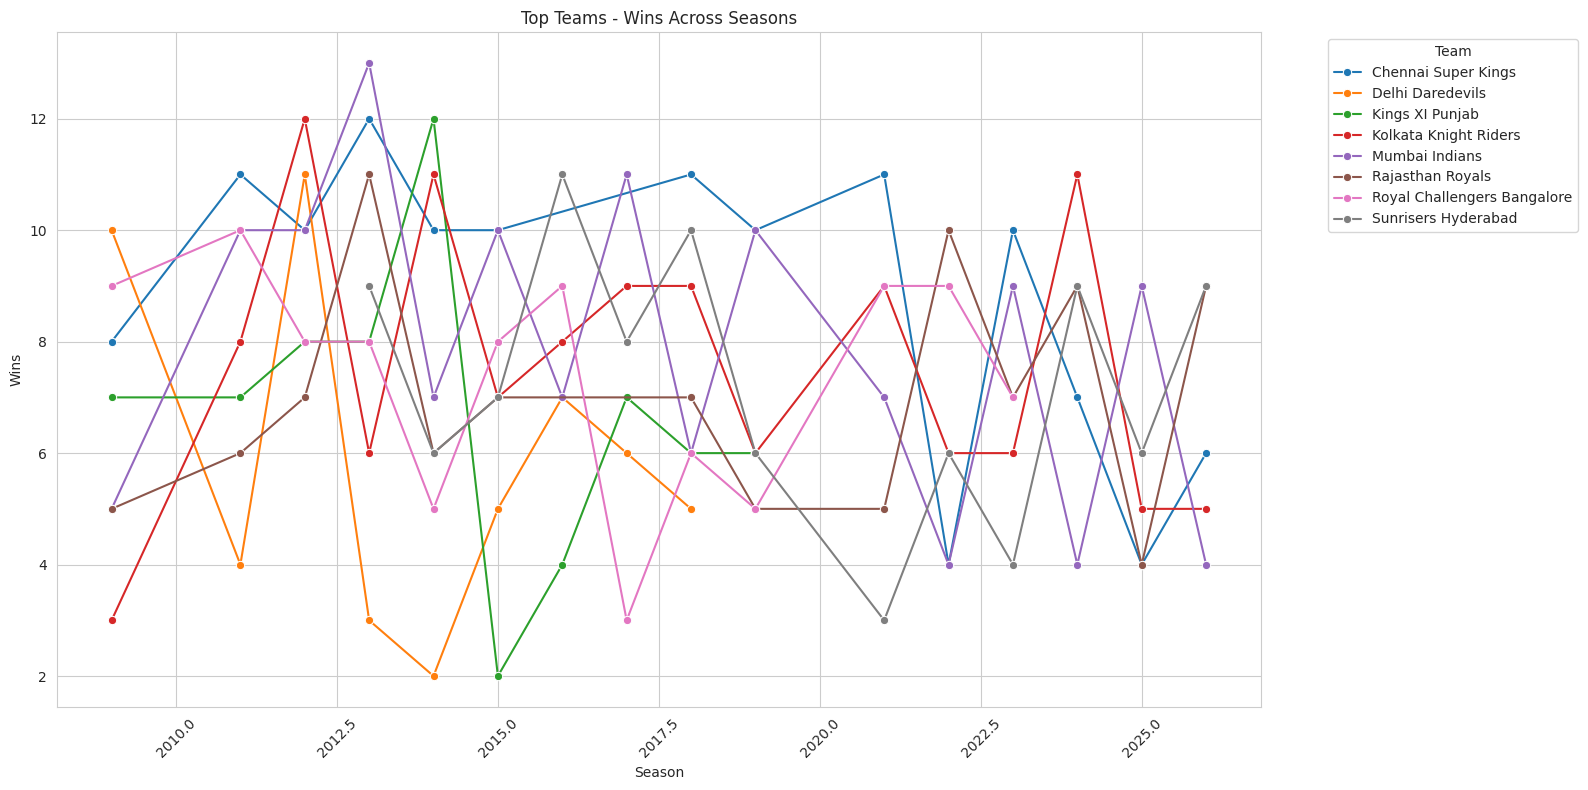

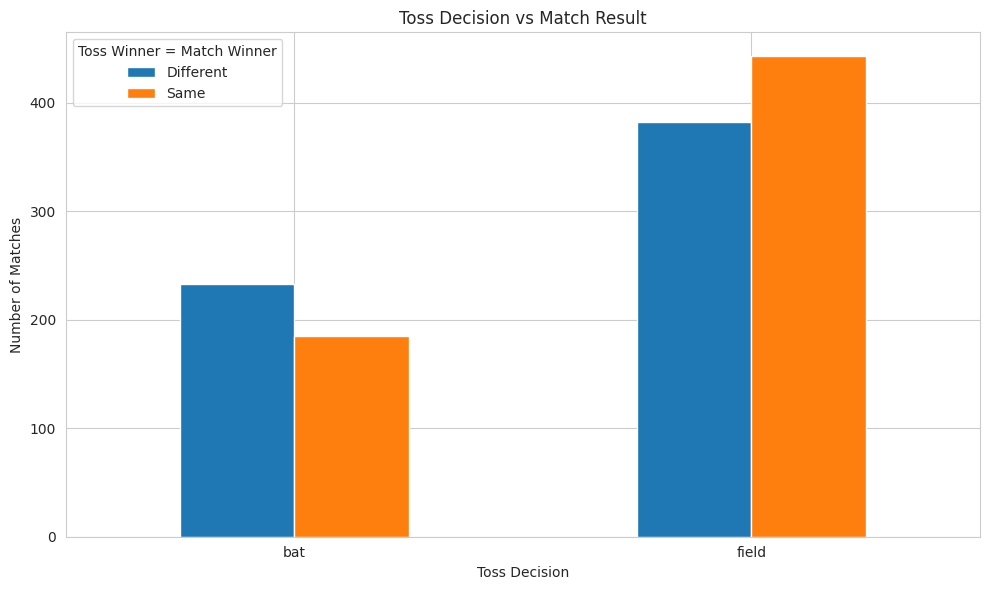


CRICKET DATASET VISUALIZATION SUMMARY
Total Matches: 1243
Total Seasons: 16
Total Teams: 19
Total Cities: 38
Total Venues: 60
Average Team 1 Runs: 165.85
Average Team 2 Runs: 157.35
Average Total Match Runs: 323.2
Toss Winner Match Success: 50.52 %

Top 10 Winning Teams:
winner
Mumbai Indians                 155
Chennai Super Kings            148
Kolkata Knight Riders          140
Rajasthan Royals               123
Royal Challengers Bangalore    114
Sunrisers Hyderabad            102
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  58
Gujarat Titans                  47
Name: count, dtype: int64

Top 10 Players of the Match:
player_of_match
AB de Villiers    25
CH Gayle          22
V Kohli           22
RG Sharma         21
SP Narine         18
DA Warner         18
MS Dhoni          18
RA Jadeja         17
KL Rahul          17
SR Watson         16
Name: count, dtype: int64

Top 10 Venues:
venue
Eden Gardens                            

In [13]:
# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# ------------------------------------------------------------
# 2. DATA CLEANING
# ------------------------------------------------------------

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Convert numeric columns to numeric
numeric_columns = [
    "season",
    "match_number",
    "team1_runs",
    "team1_wickets",
    "team2_runs",
    "team2_wickets",
    "win_by_runs",
    "win_by_wickets",
    "overs_limit",
    "balls_per_over"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove completely duplicated rows
df = df.drop_duplicates()

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ============================================================
# 3. MISSING VALUES VISUALIZATION
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=missing.values,
        y=missing.index
    )
    plt.title("Missing Values by Column")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

# ============================================================
# 4. MATCHES BY SEASON
# ============================================================

season_counts = df["season"].value_counts().sort_index()

plt.figure(figsize=(14, 6))
sns.barplot(
    x=season_counts.index.astype(str),
    y=season_counts.values
)
plt.title("Number of Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 5. MATCHES OVER TIME
# ============================================================

matches_by_date = (
    df.groupby("date")
      .size()
      .reset_index(name="matches")
      .sort_values("date")
)

plt.figure(figsize=(15, 6))
sns.lineplot(
    data=matches_by_date,
    x="date",
    y="matches"
)
plt.title("Matches Played Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 6. TOP TEAMS BY NUMBER OF MATCHES
# ============================================================

team1_counts = df["team1"].value_counts()
team2_counts = df["team2"].value_counts()

total_matches_by_team = (
    team1_counts.add(team2_counts, fill_value=0)
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))
sns.barplot(
    x=total_matches_by_team.values,
    y=total_matches_by_team.index
)
plt.title("Teams by Number of Matches Played")
plt.xlabel("Number of Matches")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

# ============================================================
# 7. TOP WINNING TEAMS
# ============================================================

winner_counts = df["winner"].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(
    x=winner_counts.values,
    y=winner_counts.index
)
plt.title("Top 15 Teams by Number of Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

# ============================================================
# 8. WINNER DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 7))
winner_counts = df["winner"].value_counts().head(10)

sns.barplot(
    x=winner_counts.index,
    y=winner_counts.values
)

plt.title("Top 10 Winning Teams")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 9. TOSS WINNER DISTRIBUTION
# ============================================================

toss_counts = df["toss_winner"].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(
    x=toss_counts.values,
    y=toss_counts.index
)
plt.title("Teams Winning the Toss Most Often")
plt.xlabel("Toss Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

# ============================================================
# 10. TOSS DECISION DISTRIBUTION
# ============================================================

toss_decision_counts = df["toss_decision"].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    toss_decision_counts.values,
    labels=toss_decision_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Toss Decision Distribution")
plt.tight_layout()
plt.show()

# ============================================================
# 11. TOSS DECISION BY SEASON
# ============================================================

toss_season = pd.crosstab(
    df["season"],
    df["toss_decision"]
)

toss_season.plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Toss Decisions by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.legend(title="Toss Decision")
plt.tight_layout()
plt.show()

# ============================================================
# 12. TOSS WINNER vs MATCH WINNER
# ============================================================

df["toss_match_winner"] = np.where(
    df["toss_winner"] == df["winner"],
    "Same",
    "Different"
)

toss_match_result = df["toss_match_winner"].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(
    x=toss_match_result.index,
    y=toss_match_result.values
)

plt.title("Toss Winner vs Match Winner")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

# Toss winner success percentage
toss_success_rate = (
    (df["toss_winner"] == df["winner"]).mean() * 100
)

print(
    f"\nToss Winner Also Won Match: "
    f"{toss_success_rate:.2f}%"
)

# ============================================================
# 13. MATCH RESULT TYPE
# ============================================================

result_counts = df["result_type"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=result_counts.index,
    y=result_counts.values
)

plt.title("Match Result Type Distribution")
plt.xlabel("Result Type")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 14. MATCH TYPE DISTRIBUTION
# ============================================================

match_type_counts = df["match_type"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=match_type_counts.index,
    y=match_type_counts.values
)

plt.title("Match Type Distribution")
plt.xlabel("Match Type")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 15. GENDER DISTRIBUTION
# ============================================================

gender_counts = df["gender"].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Matches by Gender")
plt.tight_layout()
plt.show()

# ============================================================
# 16. TEAM TYPE DISTRIBUTION
# ============================================================

team_type_counts = df["team_type"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=team_type_counts.index,
    y=team_type_counts.values
)

plt.title("Matches by Team Type")
plt.xlabel("Team Type")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 17. MATCHES BY CITY
# ============================================================

city_counts = df["city"].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(
    x=city_counts.values,
    y=city_counts.index
)

plt.title("Top 15 Cities by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# ============================================================
# 18. MATCHES BY VENUE
# ============================================================

venue_counts = df["venue"].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(
    x=venue_counts.values,
    y=venue_counts.index
)

plt.title("Top 15 Venues by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()

# ============================================================
# 19. TEAM 1 RUNS DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))
sns.histplot(
    df["team1_runs"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Team 1 Runs")
plt.xlabel("Team 1 Runs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 20. TEAM 2 RUNS DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))
sns.histplot(
    df["team2_runs"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Team 2 Runs")
plt.xlabel("Team 2 Runs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 21. TEAM 1 vs TEAM 2 RUNS
# ============================================================

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="team1_runs",
    y="team2_runs",
    alpha=0.6
)

plt.title("Team 1 Runs vs Team 2 Runs")
plt.xlabel("Team 1 Runs")
plt.ylabel("Team 2 Runs")
plt.tight_layout()
plt.show()

# ============================================================
# 22. RUNS DISTRIBUTION USING BOXPLOT
# ============================================================

runs_data = df[
    ["team1_runs", "team2_runs"]
].melt(
    var_name="Team",
    value_name="Runs"
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=runs_data,
    x="Team",
    y="Runs"
)

plt.title("Runs Distribution Comparison")
plt.xlabel("Team")
plt.ylabel("Runs")
plt.tight_layout()
plt.show()

# ============================================================
# 23. TEAM 1 WICKETS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))
sns.histplot(
    df["team1_wickets"].dropna(),
    discrete=True
)

plt.title("Team 1 Wickets Distribution")
plt.xlabel("Wickets")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

# ============================================================
# 24. TEAM 2 WICKETS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))
sns.histplot(
    df["team2_wickets"].dropna(),
    discrete=True
)

plt.title("Team 2 Wickets Distribution")
plt.xlabel("Wickets")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

# ============================================================
# 25. WIN BY RUNS DISTRIBUTION
# ============================================================

win_runs = df[df["win_by_runs"] > 0]["win_by_runs"]

plt.figure(figsize=(12, 6))
sns.histplot(
    win_runs.dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Wins by Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 26. WIN BY WICKETS DISTRIBUTION
# ============================================================

win_wickets = df[df["win_by_wickets"] > 0]["win_by_wickets"]

plt.figure(figsize=(10, 6))
sns.countplot(
    x=win_wickets.dropna()
)

plt.title("Distribution of Wins by Wickets")
plt.xlabel("Wickets")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

# ============================================================
# 27. WIN MARGIN COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[
        ["win_by_runs", "win_by_wickets"]
    ]
)

plt.title("Win Margin Distribution")
plt.xlabel("Win Margin Type")
plt.ylabel("Margin")
plt.tight_layout()
plt.show()

# ============================================================
# 28. TOP PLAYERS OF THE MATCH
# ============================================================

pom_counts = (
    df["player_of_match"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    x=pom_counts.values,
    y=pom_counts.index
)

plt.title("Top 20 Players of the Match")
plt.xlabel("Player of the Match Awards")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

# ============================================================
# 29. PLAYER OF MATCH AWARDS OVER SEASON
# ============================================================

pom_season = (
    df.groupby("season")["player_of_match"]
      .count()
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    x=pom_season.index,
    y=pom_season.values,
    marker="o"
)

plt.title("Player of the Match Awards by Season")
plt.xlabel("Season")
plt.ylabel("Awards")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 30. MATCHES BY MONTH
# ============================================================

df["month"] = df["date"].dt.month

month_counts = df["month"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=month_counts.index,
    y=month_counts.values
)

plt.title("Number of Matches by Month")
plt.xlabel("Month")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

# ============================================================
# 31. MATCHES BY DAY OF WEEK
# ============================================================

df["day_of_week"] = df["date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_counts = (
    df["day_of_week"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=day_counts.index,
    y=day_counts.values
)

plt.title("Matches by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 32. AVERAGE TEAM 1 AND TEAM 2 RUNS BY SEASON
# ============================================================

season_runs = (
    df.groupby("season")[
        ["team1_runs", "team2_runs"]
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=season_runs,
    x="season",
    y="team1_runs",
    marker="o",
    label="Team 1 Average Runs"
)

sns.lineplot(
    data=season_runs,
    x="season",
    y="team2_runs",
    marker="o",
    label="Team 2 Average Runs"
)

plt.title("Average Runs by Season")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 33. TOTAL RUNS BY SEASON
# ============================================================

df["total_match_runs"] = (
    df["team1_runs"].fillna(0)
    + df["team2_runs"].fillna(0)
)

total_runs_season = (
    df.groupby("season")["total_match_runs"]
      .sum()
)

plt.figure(figsize=(15, 7))
sns.lineplot(
    x=total_runs_season.index,
    y=total_runs_season.values,
    marker="o"
)

plt.title("Total Runs Scored by Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 34. AVERAGE WIN BY RUNS BY SEASON
# ============================================================

avg_win_runs = (
    df[df["win_by_runs"] > 0]
    .groupby("season")["win_by_runs"]
    .mean()
)

plt.figure(figsize=(15, 6))
sns.lineplot(
    x=avg_win_runs.index,
    y=avg_win_runs.values,
    marker="o"
)

plt.title("Average Win Margin by Runs Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 35. CORRELATION HEATMAP
# ============================================================

correlation_columns = [
    "season",
    "match_number",
    "team1_runs",
    "team1_wickets",
    "team2_runs",
    "team2_wickets",
    "win_by_runs",
    "win_by_wickets",
    "overs_limit",
    "balls_per_over"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# ============================================================
# 36. PAIRPLOT
# ============================================================

pair_columns = [
    "team1_runs",
    "team2_runs",
    "team1_wickets",
    "team2_wickets",
    "win_by_runs",
    "win_by_wickets"
]

sns.pairplot(
    df[pair_columns].dropna()
)

plt.suptitle(
    "Pairwise Relationship Between Match Statistics",
    y=1.02
)

plt.show()

# ============================================================
# 37. TOP TEAM vs TEAM MATCHUPS
# ============================================================

matchups = (
    df.groupby(["team1", "team2"])
      .size()
      .reset_index(name="matches")
      .sort_values("matches", ascending=False)
      .head(15)
)

matchups["matchup"] = (
    matchups["team1"]
    + " vs "
    + matchups["team2"]
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=matchups,
    x="matches",
    y="matchup"
)

plt.title("Top 15 Team vs Team Matchups")
plt.xlabel("Number of Matches")
plt.ylabel("Matchup")
plt.tight_layout()
plt.show()

# ============================================================
# 38. WINNER BY SEASON - TOP TEAMS
# ============================================================

top_teams = df["winner"].value_counts().head(8).index

winner_season = (
    df[df["winner"].isin(top_teams)]
    .groupby(["season", "winner"])
    .size()
    .reset_index(name="wins")
)

plt.figure(figsize=(16, 8))

sns.lineplot(
    data=winner_season,
    x="season",
    y="wins",
    hue="winner",
    marker="o"
)

plt.title("Top Teams - Wins Across Seasons")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.legend(title="Team", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ============================================================
# 39. TOSS DECISION vs MATCH RESULT
# ============================================================

toss_result = pd.crosstab(
    df["toss_decision"],
    df["toss_match_winner"]
)

toss_result.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Toss Decision vs Match Result")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.legend(title="Toss Winner = Match Winner")
plt.tight_layout()
plt.show()

# ============================================================
# 40. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("CRICKET DATASET VISUALIZATION SUMMARY")
print("=" * 60)

print("Total Matches:", len(df))
print("Total Seasons:", df["season"].nunique())
print("Total Teams:", pd.unique(
    pd.concat([df["team1"], df["team2"]])
).size)

print("Total Cities:", df["city"].nunique())
print("Total Venues:", df["venue"].nunique())

print(
    "Average Team 1 Runs:",
    round(df["team1_runs"].mean(), 2)
)

print(
    "Average Team 2 Runs:",
    round(df["team2_runs"].mean(), 2)
)

print(
    "Average Total Match Runs:",
    round(df["total_match_runs"].mean(), 2)
)

print(
    "Toss Winner Match Success:",
    round(toss_success_rate, 2),
    "%"
)

print("\nTop 10 Winning Teams:")
print(df["winner"].value_counts().head(10))

print("\nTop 10 Players of the Match:")
print(df["player_of_match"].value_counts().head(10))

print("\nTop 10 Venues:")
print(df["venue"].value_counts().head(10))

print("\nTop 10 Cities:")
print(df["city"].value_counts().head(10))

## Feature engineering

Dataset Shape:
(1243, 35)

Columns:
Index(['event_name', 'season', 'match_number', 'date', 'city', 'venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'team1_runs',
       'team1_wickets', 'team2_runs', 'team2_wickets', 'winner', 'result_type',
       'win_by_runs', 'win_by_wickets', 'player_of_match', 'match_referee',
       'umpire1', 'umpire2', 'tv_umpire', 'reserve_umpire', 'match_type',
       'overs_limit', 'balls_per_over', 'gender', 'team_type', 'team1_players',
       'team2_players', 'toss_match_winner', 'month', 'day_of_week',
       'total_match_runs'],
      dtype='object')

First 5 Records:
              event_name  season  match_number       date        city  \
0  Indian Premier League     NaN           1.0 2008-04-18   Bangalore   
1  Indian Premier League     NaN           2.0 2008-04-19  Chandigarh   
2  Indian Premier League     NaN           3.0 2008-04-19       Delhi   
3  Indian Premier League     NaN           4.0 2008-04-20     Kolkata   
4  Indian

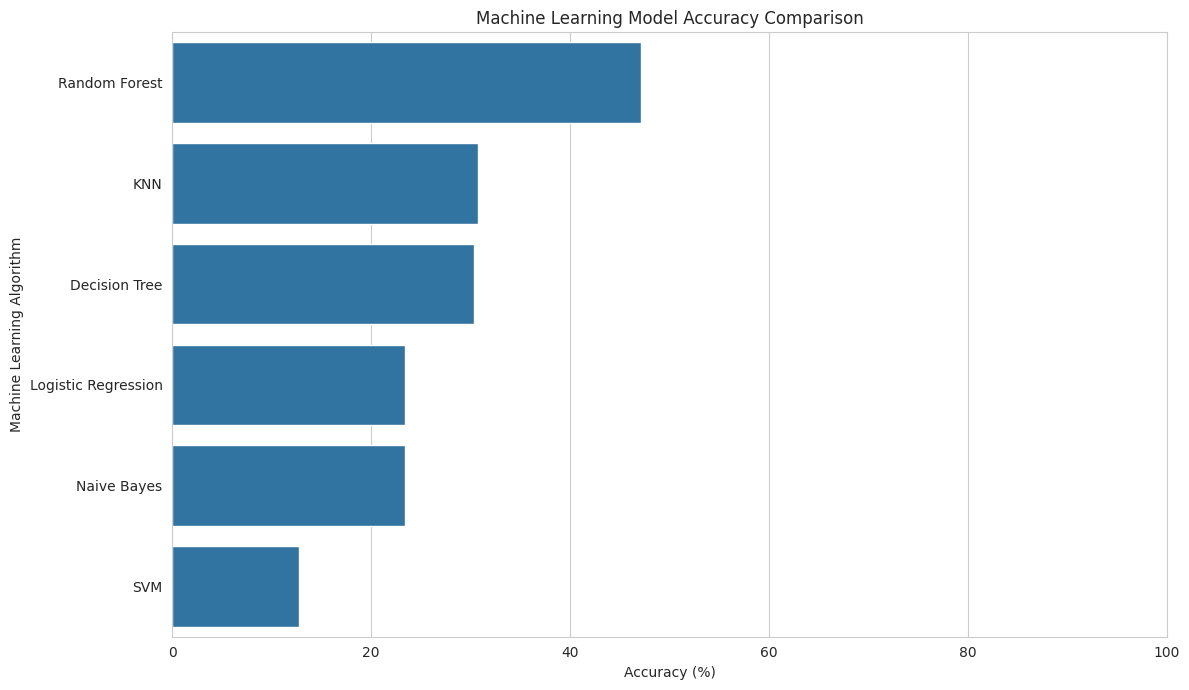



FINAL ACCURACY RESULTS
Random Forest: 47.13%
KNN: 30.74%
Decision Tree: 30.33%
Logistic Regression: 23.36%
Naive Bayes: 23.36%
SVM: 12.70%


BEST MODEL
Best Algorithm: Random Forest
Best Accuracy: 47.13%


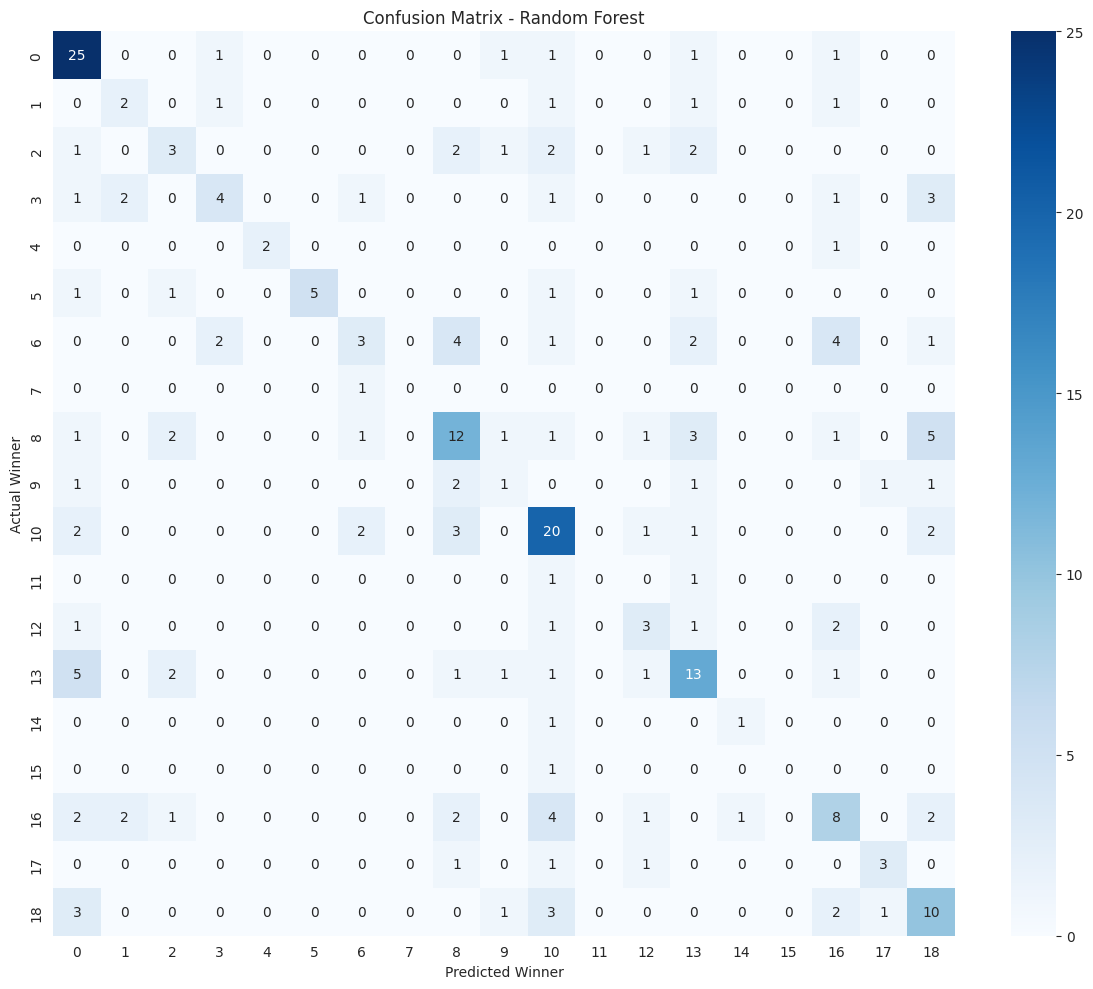



CLASSIFICATION REPORT - Random Forest
                             precision    recall  f1-score   support

        Chennai Super Kings       0.58      0.83      0.68        30
            Deccan Chargers       0.33      0.33      0.33         6
             Delhi Capitals       0.33      0.25      0.29        12
           Delhi Daredevils       0.50      0.31      0.38        13
              Gujarat Lions       1.00      0.67      0.80         3
             Gujarat Titans       1.00      0.56      0.71         9
            Kings XI Punjab       0.38      0.18      0.24        17
       Kochi Tuskers Kerala       0.00      0.00      0.00         1
      Kolkata Knight Riders       0.44      0.43      0.44        28
       Lucknow Super Giants       0.17      0.14      0.15         7
             Mumbai Indians       0.49      0.65      0.56        31
              Pune Warriors       0.00      0.00      0.00         2
               Punjab Kings       0.33      0.38      0.35    

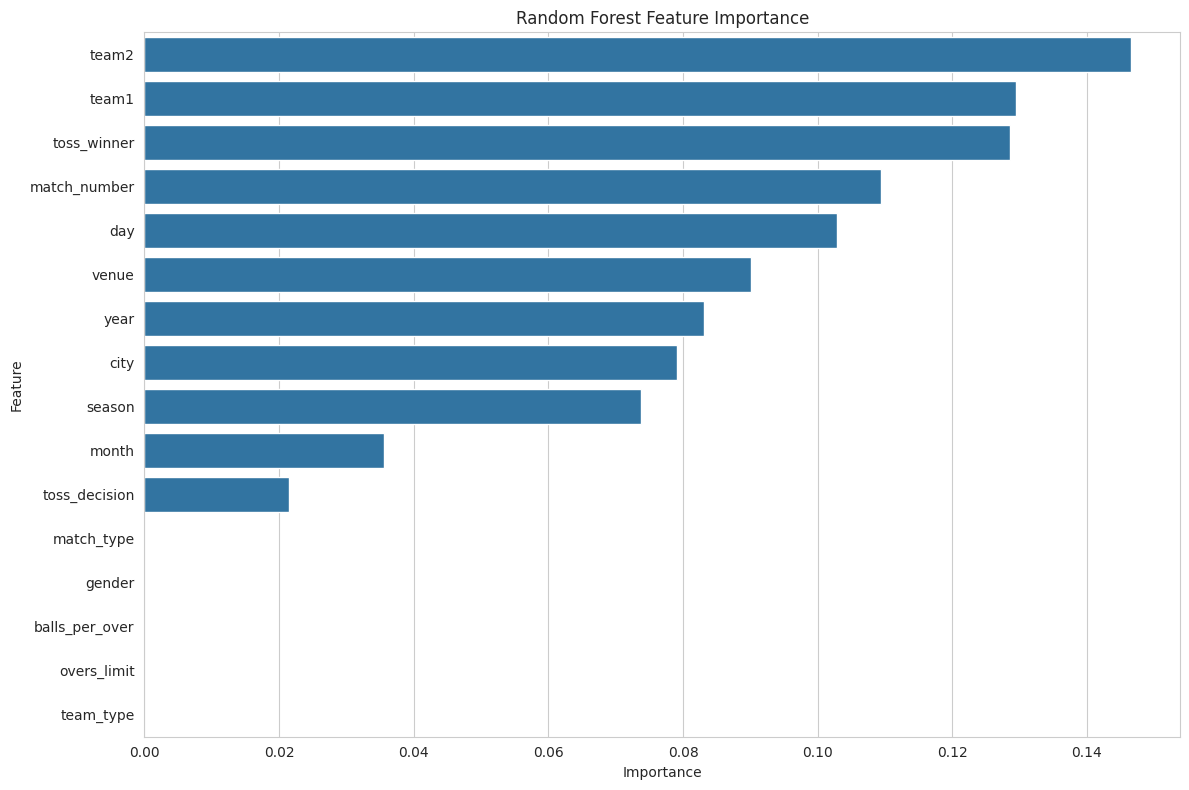



ACTUAL VS PREDICTED WINNER
                         Actual                    Predicted
0              Rajasthan Royals               Delhi Capitals
1              Delhi Daredevils          Sunrisers Hyderabad
2               Kings XI Punjab              Kings XI Punjab
3              Rajasthan Royals             Rajasthan Royals
4   Royal Challengers Bangalore          Chennai Super Kings
5   Royal Challengers Bengaluru  Royal Challengers Bengaluru
6   Royal Challengers Bangalore               Mumbai Indians
7         Kolkata Knight Riders             Rajasthan Royals
8   Royal Challengers Bangalore              Deccan Chargers
9                  Punjab Kings          Chennai Super Kings
10  Royal Challengers Bangalore  Royal Challengers Bangalore
11  Royal Challengers Bangalore          Chennai Super Kings
12               Mumbai Indians               Mumbai Indians
13        Kolkata Knight Riders        Kolkata Knight Riders
14        Kolkata Knight Riders        Kolkata Knight Ri

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC




print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Records:")
print(df.head())


# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(df.shape)


# ============================================================
# 5. CONVERT DATE COLUMN
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)


# ============================================================
# 6. CREATE DATE FEATURES
# ============================================================

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day


# ============================================================
# 7. HANDLE MISSING TARGET VALUES
# ============================================================

df = df.dropna(subset=["winner"])

print("\nTarget Distribution:")
print(df["winner"].value_counts())


# ============================================================
# 8. SELECT FEATURES
# ============================================================

# Target:
# winner

# We intentionally remove:
# - winner              -> target
# - win_by_runs         -> known only after match
# - win_by_wickets      -> known only after match
# - player_of_match     -> known after match
# - match_referee       -> post-match/official information
# - umpire information  -> generally not useful for this prediction
# - player lists        -> very high-cardinality text
# - date                -> converted into year/month/day

features = [
    "season",
    "match_number",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "match_type",
    "overs_limit",
    "balls_per_over",
    "gender",
    "team_type",
    "year",
    "month",
    "day"
]

target = "winner"


# ============================================================
# 9. CHECK WHETHER FEATURES EXIST
# ============================================================

available_features = [
    col for col in features
    if col in df.columns
]

print("\nFeatures Used:")
print(available_features)

X = df[available_features].copy()
y = df[target].copy()


# ============================================================
# 10. HANDLE MISSING VALUES
# ============================================================

# Numerical columns
numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_cols:
    X[col] = X[col].fillna(
        X[col].median()
    )


# Categorical columns
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

for col in categorical_cols:
    X[col] = X[col].fillna(
        X[col].mode()[0]
    )


# ============================================================
# 11. LABEL ENCODING
# ============================================================

# Dictionary to store encoders
encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    encoders[col] = le

    print(
        f"\nLabel Encoding for: {col}"
    )

    mapping = dict(
        zip(
            le.classes_,
            le.transform(le.classes_)
        )
    )

    print(mapping)


# ============================================================
# 12. ENCODE TARGET VARIABLE
# ============================================================

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(
    y.astype(str)
)

print("\nTarget Encoding:")
print(
    dict(
        zip(
            target_encoder.classes_,
            target_encoder.transform(
                target_encoder.classes_
            )
        )
    )
)


# ============================================================
# 13. DISPLAY FINAL FEATURES
# ============================================================

print("\nFinal X Shape:")
print(X.shape)

print("\nFinal y Shape:")
print(y_encoded.shape)

print("\nFinal Feature Data:")
print(X.head())


# ============================================================
# 14. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain Data Shape:")
print(X_train.shape)

print("\nTest Data Shape:")
print(X_test.shape)

print(
    "\nTraining Percentage:",
    round(len(X_train) / len(X) * 100, 2),
    "%"
)

print(
    "Testing Percentage:",
    round(len(X_test) / len(X) * 100, 2),
    "%"
)


# ============================================================
# 15. MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            kernel="rbf",
            random_state=42
        )
}


# ============================================================
# 16. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Prediction
    y_pred = model.predict(
        X_test
    )

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    accuracy_percentage = accuracy * 100

    print(
        "Accuracy:",
        round(accuracy_percentage, 2),
        "%"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_percentage
    })

    trained_models[name] = model


# ============================================================
# 17. MODEL ACCURACY COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("=" * 60)
print("MODEL ACCURACY COMPARISON")
print("=" * 60)

print(results_df)


# ============================================================
# 18. ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title(
    "Machine Learning Model Accuracy Comparison"
)

plt.xlabel(
    "Accuracy (%)"
)

plt.ylabel(
    "Machine Learning Algorithm"
)

plt.xlim(0, 100)

plt.tight_layout()
plt.show()


# ============================================================
# 19. PRINT ACCURACY WITH PERCENTAGE
# ============================================================

print("\n")
print("=" * 60)
print("FINAL ACCURACY RESULTS")
print("=" * 60)

for index, row in results_df.iterrows():

    print(
        f"{row['Model']}: "
        f"{row['Accuracy']:.2f}%"
    )


# ============================================================
# 20. BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy"]

print("\n")
print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(
    "Best Algorithm:",
    best_model_name
)

print(
    "Best Accuracy:",
    f"{best_accuracy:.2f}%"
)


# ============================================================
# 21. CONFUSION MATRIX FOR BEST MODEL
# ============================================================

best_model = trained_models[
    best_model_name
]

best_predictions = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted Winner"
)

plt.ylabel(
    "Actual Winner"
)

plt.tight_layout()
plt.show()


# ============================================================
# 22. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 60)
print(
    f"CLASSIFICATION REPORT - {best_model_name}"
)
print("=" * 60)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# 23. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

if "Random Forest" in trained_models:

    rf_model = trained_models[
        "Random Forest"
    ]

    feature_importance = pd.DataFrame({

        "Feature":
            X.columns,

        "Importance":
            rf_model.feature_importances_

    })

    feature_importance = (
        feature_importance
        .sort_values(
            by="Importance",
            ascending=False
        )
    )

    print("\n")
    print("=" * 60)
    print("RANDOM FOREST FEATURE IMPORTANCE")
    print("=" * 60)

    print(
        feature_importance
    )


    # Feature importance visualization

    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=feature_importance,
        x="Importance",
        y="Feature"
    )

    plt.title(
        "Random Forest Feature Importance"
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. ACTUAL vs PREDICTED WINNER
# ============================================================

comparison = pd.DataFrame({

    "Actual":
        target_encoder.inverse_transform(
            y_test
        ),

    "Predicted":
        target_encoder.inverse_transform(
            best_predictions
        )

})

print("\n")
print("=" * 60)
print("ACTUAL VS PREDICTED WINNER")
print("=" * 60)

print(
    comparison.head(30)
)


# ============================================================
# 25. PREDICTION ACCURACY COUNT
# ============================================================

correct_predictions = (
    y_test == best_predictions
).sum()

incorrect_predictions = (
    y_test != best_predictions
).sum()

total_predictions = len(y_test)

print("\n")
print("=" * 60)
print("PREDICTION SUMMARY")
print("=" * 60)

print(
    "Total Test Records:",
    total_predictions
)

print(
    "Correct Predictions:",
    correct_predictions
)

print(
    "Incorrect Predictions:",
    incorrect_predictions
)

print(
    "Accuracy:",
    f"{(correct_predictions / total_predictions) * 100:.2f}%"
)


# ============================================================
# 26. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("CRICKET WINNER PREDICTION - FINAL SUMMARY")
print("=" * 70)

print(
    "Dataset Records:",
    len(df)
)

print(
    "Number of Features:",
    X.shape[1]
)

print(
    "Training Records:",
    len(X_train)
)

print(
    "Testing Records:",
    len(X_test)
)

print(
    "Number of Teams:",
    len(target_encoder.classes_)
)

print(
    "Best Model:",
    best_model_name
)

print(
    "Best Accuracy:",
    f"{best_accuracy:.2f}%"
)

print("=" * 70)

## Thank you..pls upvote!!!!!!!!!!